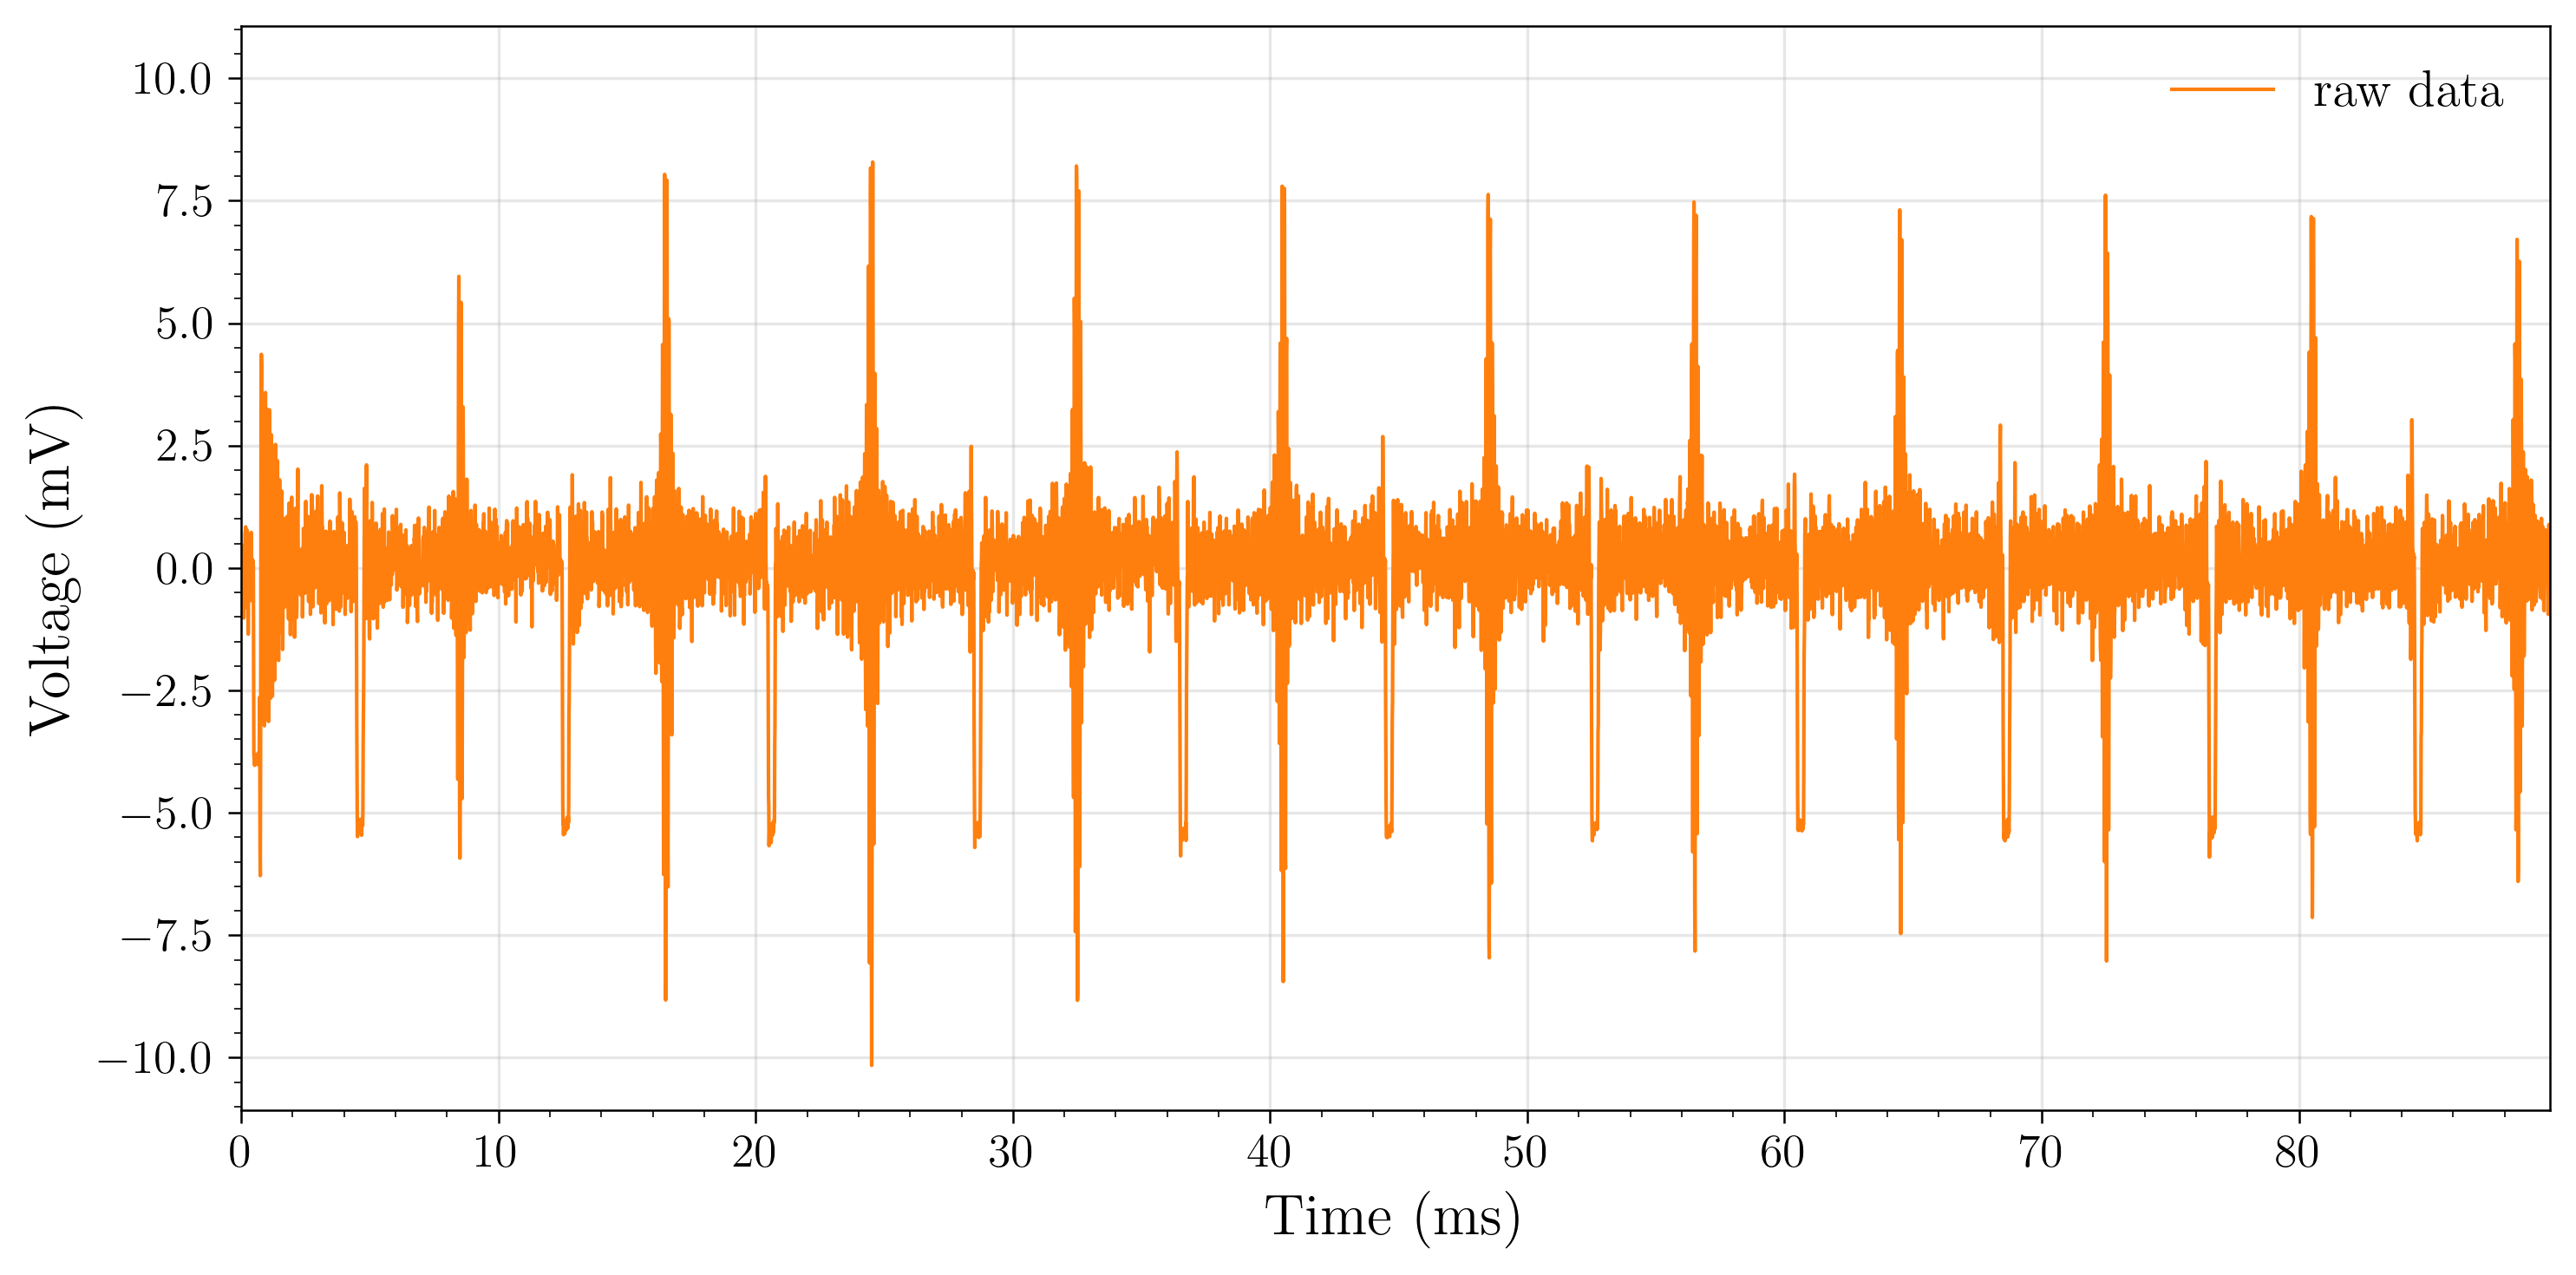

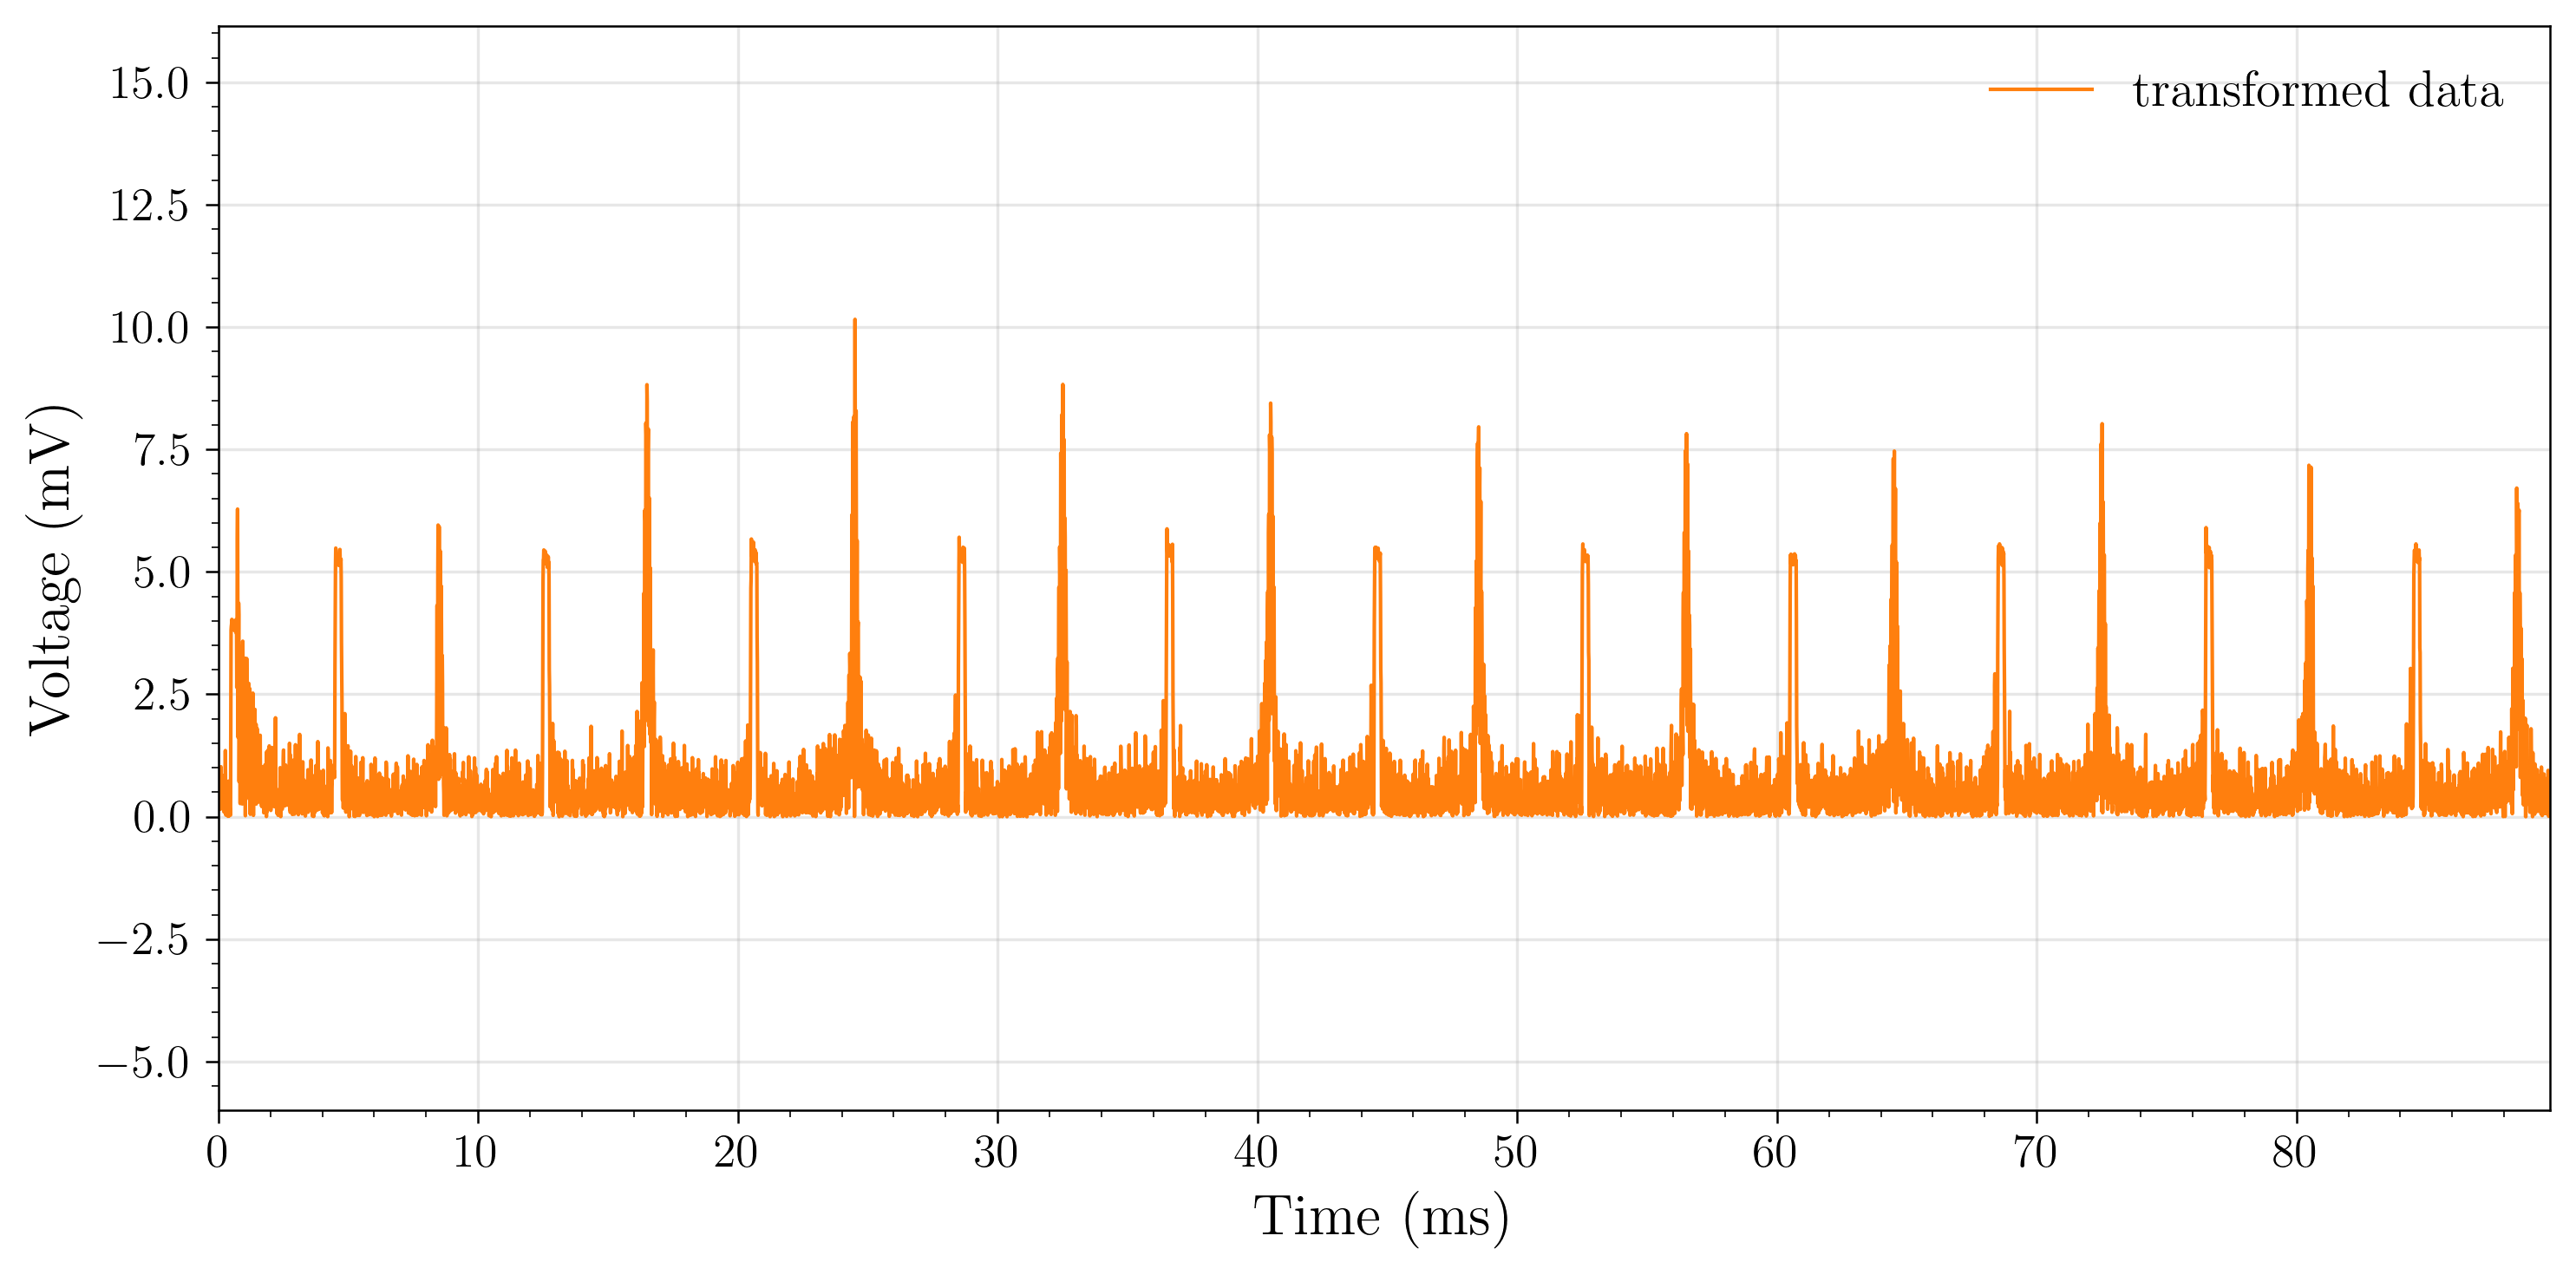

Detected 12 CH1 peaks; T = 8002.00 µs; 11 echo estimates; method: Lorentzian (Hilbert envelope)


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, hilbert
from scipy.optimize import curve_fit

plt.style.use('./jlab.mplstyle')

# Uniform large text on every plot in the notebook.
plt.rcParams.update({
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 14,
})

# --- Echo amplitude method options ---
# USE_LORENTZIAN=True  → for each echo window, take the Hilbert envelope
#                        |H[CH2(t)]| and fit
#                        L(t) = A / (1 + ((t-t0)/gamma)^2)
#                        (zero-baseline; c is fixed to 0).
#                        Echo amplitude = A; uncertainty = sqrt(pcov[0,0]).
# USE_LORENTZIAN=False → take N_EXTREMA most positive + N_EXTREMA most
#                        negative CH2 samples; amplitude = mean(|points|),
#                        uncertainty = SEM. (Total 2*N_EXTREMA points.)
USE_LORENTZIAN = True
N_EXTREMA      = 16   # only used by the legacy (non-Lorentzian) method

# --- Load the example file (tek0000) and AC-couple every channel.
df = pd.read_csv('data/tek0000.csv', skiprows=20)
df = df[['TIME', 'CH1', 'CH2', 'CH3']].apply(pd.to_numeric, errors='coerce').dropna()

t       = df['TIME'].to_numpy()
ch1_raw = df['CH1'].to_numpy(copy=True)
ch2_raw = df['CH2'].to_numpy(copy=True)
ch3_raw = df['CH3'].to_numpy(copy=True)
ch1 = ch1_raw - ch1_raw.mean()
ch2 = ch2_raw - ch2_raw.mean()
ch3 = ch3_raw - ch3_raw.mean()

# Common axis dimensions for the animation frames (Step 0/1/2/2-fit)
# rendered in mV so the y-tick labels read in millivolts.
STEP_FIG_DIR = 'step_figures'
os.makedirs(STEP_FIG_DIR, exist_ok=True)

_xlim_anim = (0.0, t.max() * 1e3)
# Common axis HEIGHT in mV (matches the original signed-CH2 box) so
# all four step frames have the same y-axis size; only the center
# shifts between the signed (Step 0) and rectified (Step 1/2a/2b) plots.
_yspan_mV = 1e3 * float(ch2.max() - ch2.min())
_yheight_mV = 1.2 * _yspan_mV
_ycenter_signed = 0.0
_ycenter_abs = 0.5 * 1e3 * float(np.abs(ch2).max())
_ylim_anim_signed = (_ycenter_signed - _yheight_mV / 2,
                     _ycenter_signed + _yheight_mV / 2)
_ylim_anim_abs    = (_ycenter_abs    - _yheight_mV / 2,
                     _ycenter_abs    + _yheight_mV / 2)
_ylim_anim = _ylim_anim_abs  # default for downstream cells

# --- Step 0 plot: raw CH2.
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t * 1e3, ch2 * 1e3, color='tab:orange', lw=1.0,
        label='raw data')
ax.set_xlim(_xlim_anim); ax.set_ylim(_ylim_anim_signed)
ax.set_xlabel('Time (ms)', fontsize=16)
ax.set_ylabel('Voltage (mV)', fontsize=16)
ax.tick_params(labelsize=13)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=14)
plt.tight_layout()
fig.savefig(os.path.join(STEP_FIG_DIR, 'step0_raw_ch2.png'), dpi=150, bbox_inches='tight')
plt.show()

# Scale CH1 onto CH2's amplitude so they're comparable on a single panel.
ch2_max = np.max(np.abs(ch2))
ch1_scaled = ch1 * (ch2_max / np.max(np.abs(ch1)))

# --- Detect CH1 ± trigger peaks (90° + 180° pulses).
ch1_abs = np.abs(ch1)
peaks, _ = find_peaks(ch1_abs, prominence=0.20 * np.max(ch1_abs), distance=50)
peak_times = t[peaks]

# --- Assume uniform 180° spacing; drop the 90° (peak 0) and refine T over
# the full span. Build the inferred 180° grid with one extrapolated step
# past the trace so the final echo midpoint is recovered.
later = peak_times[1:]
T_unit = np.min(np.diff(later))
span = later[-1] - later[0]
n_int = int(round(span / T_unit))
T = span / n_int
n_in_data = int(np.floor((t[-1] - later[0]) / T)) + 1
n_total = n_in_data + 1
t_180_grid = later[0] + np.arange(n_total) * T
echo_times = t_180_grid[:-1] + T / 2

# Echo search window: ±window_s around each estimated echo.
window_s = 0.5e-3

# Shared baseline `c` for every Lorentzian fit on this file. The
# median of |H[CH2]| over the full trace is a robust noise-floor
# estimator (echoes are sparse peaks above the floor).
c_fixed_ex = float(np.median(np.abs(hilbert(ch2))))


# --- Echo-amplitude helpers ----------------------------------------------
def lorentzian(t, A, t0, gamma):
    return A / (1.0 + ((t - t0) / gamma) ** 2)


def fit_lorentzian_to_window(t_win, ch2_win, n_max=None, c_fixed=None):
    """Compute the Hilbert envelope of CH2 within the window
    (FFT-bandpassed around the dominant carrier first to suppress the
    out-of-band content that systematically inflates the analytic-
    signal magnitude), then fit a zero-baseline Lorentzian
    L(t) = A/(1+((t-t0)/gamma)^2) to it.

    `c_fixed` is accepted for backward compatibility but ignored.

    Returns dict(amp, amp_err, t0, t0_err, gamma, c, tp, yp,
    amp_raw, amp_stat_err, amp_sys_err, amp_shift). With
    gap = A_lorentz \u2212 |CH2|.max, `amp` is shifted by gap/2 toward
    |CH2|.max (i.e. amp = (A + |CH2|.max)/2) and `amp_err` adds
    |gap|/2 in quadrature with the statistical error."""
    n = len(ch2_win)
    if n < 8:
        return None
    sample_dt = float(np.median(np.diff(t_win)))
    if not np.isfinite(sample_dt) or sample_dt <= 0:
        return None
    # Bandpass the signal: keep \u00b1~4 kHz around the dominant FFT bin,
    # zero everything else. Out-of-band content (DC residual, far-side
    # noise, FFT sidebands) is what makes |H[CH2]| sit above the true
    # carrier amplitude; removing it shrinks the overshoot from ~10\u201320%
    # to ~1\u20135% on these data.
    spec = np.fft.rfft(ch2_win)
    mag = np.abs(spec)
    mag[0] = 0.0
    fpk_bin = int(np.argmax(mag))
    if fpk_bin <= 0:
        return None
    bin_hz = 1.0 / (n * sample_dt)
    half_bins = max(3, int(round(4e3 / bin_hz)))
    bp_lo = max(1, fpk_bin - half_bins)
    bp_hi = min(len(spec), fpk_bin + half_bins + 1)
    mask = np.zeros_like(spec)
    mask[bp_lo:bp_hi] = spec[bp_lo:bp_hi]
    ch2_bp = np.fft.irfft(mask, n=n)
    env = np.abs(hilbert(ch2_bp))
    tp = t_win
    yp = env

    A0 = float(yp.max() - yp.min())
    if A0 <= 0:
        return None
    t0_0 = float(tp[np.argmax(yp)])
    span_t = float(tp[-1] - tp[0])
    if span_t <= 0:
        return None
    sample_dt = float(np.median(np.diff(tp)))
    if not np.isfinite(sample_dt) or sample_dt <= 0:
        sample_dt = span_t / max(len(tp) - 1, 1)
    gamma_0 = max(span_t / 4.0, 5 * sample_dt)

    bounds_lo = [0.0,                    tp[0],  2.0 * sample_dt]
    bounds_hi = [10.0 * float(yp.max()), tp[-1], span_t]
    p0 = [min(max(float(yp.max()), bounds_lo[0] + 1e-12), bounds_hi[0] - 1e-12),
          min(max(t0_0,            bounds_lo[1]),         bounds_hi[1]),
          min(max(gamma_0,         bounds_lo[2]),         bounds_hi[2])]
    try:
        popt, pcov = curve_fit(lorentzian, tp, yp, p0=p0,
                               bounds=(bounds_lo, bounds_hi),
                               maxfev=5000)
    except Exception:
        return None
    if not np.all(np.isfinite(pcov)):
        return None
    A, t0, gamma = popt
    diag = np.diag(pcov)
    diag = np.where(diag < 0, 0.0, diag)
    A_err  = float(np.sqrt(diag[0]))
    t0_err = float(np.sqrt(diag[1]))
    if not (np.isfinite(A) and np.isfinite(A_err)):
        return None
    A_err  = max(A_err, 1e-6 * abs(A) if A != 0 else 1e-9)
    # NOTE: no clamp on t0_err — use the raw curve_fit sigma_t.
    # Systematic correction: split the difference between the
    # fitted Lorentzian peak A and the discrete |CH2| peak.
    # Signed gap; sign matters for the shift but not for the
    # quadrature-added systematic uncertainty.
    data_peak    = float(np.abs(ch2_win).max())
    gap          = float(A) - data_peak
    delta        = abs(gap)
    A_shift      = 0.5 * gap
    A_sys_err    = 0.5 * delta
    A_corr       = float(A) - A_shift
    A_total_err  = float(np.sqrt(A_err ** 2 + A_sys_err ** 2))
    return dict(amp=A_corr, amp_err=A_total_err,
                amp_raw=float(A), amp_stat_err=A_err,
                amp_sys_err=float(A_sys_err), amp_shift=float(A_shift),
                t0=float(t0),  t0_err=t0_err,
                gamma=float(gamma), c=0.0, tp=tp, yp=yp)


def compute_echo_amplitude(t_win, ch2_win, c_fixed=None):
    """Return (echo_t, amp, amp_unc, t_unc) for one echo, or None.
    Branches on USE_LORENTZIAN."""
    if USE_LORENTZIAN:
        r = fit_lorentzian_to_window(t_win, ch2_win,
                                     n_max=N_EXTREMA, c_fixed=c_fixed)
        if r is None:
            return None
        return r['t0'], r['amp'], r['amp_err'], r['t0_err']
    # Legacy: top N_EXTREMA most positive + most negative CH2 samples
    if len(ch2_win) < 2 * N_EXTREMA:
        return None
    order = np.argsort(ch2_win)
    sel = np.concatenate([order[-N_EXTREMA:], order[:N_EXTREMA]])
    ey = ch2_win[sel]
    tx = t_win[sel]
    absv = np.abs(ey)
    return (float(np.mean(tx)),
            float(np.mean(absv)),
            float(np.std(absv, ddof=1) / np.sqrt(len(absv))),
            float((tx.max() - tx.min()) / 2))


# --- Step 1 plot: rectify the signal — |CH2 raw|. Same axis box
# as Step 0 so it reads like an animation frame.
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t * 1e3, np.abs(ch2) * 1e3, color='tab:orange', lw=1.0,
        label='transformed data')
ax.set_xlim(_xlim_anim); ax.set_ylim(_ylim_anim_abs)
ax.set_xlabel('Time (ms)', fontsize=16)
ax.set_ylabel('Voltage (mV)', fontsize=16)
ax.tick_params(labelsize=13)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=14)
plt.tight_layout()
fig.savefig(os.path.join(STEP_FIG_DIR, 'step1_abs_ch2.png'), dpi=150, bbox_inches='tight')
plt.show()

method = ('Lorentzian (Hilbert envelope)' if USE_LORENTZIAN
          else f'{2*N_EXTREMA}-point extrema')
print(f"Detected {len(peaks)} CH1 peaks; T = {T*1e6:.2f} µs; "
      f"{len(echo_times)} echo estimates; method: {method}")

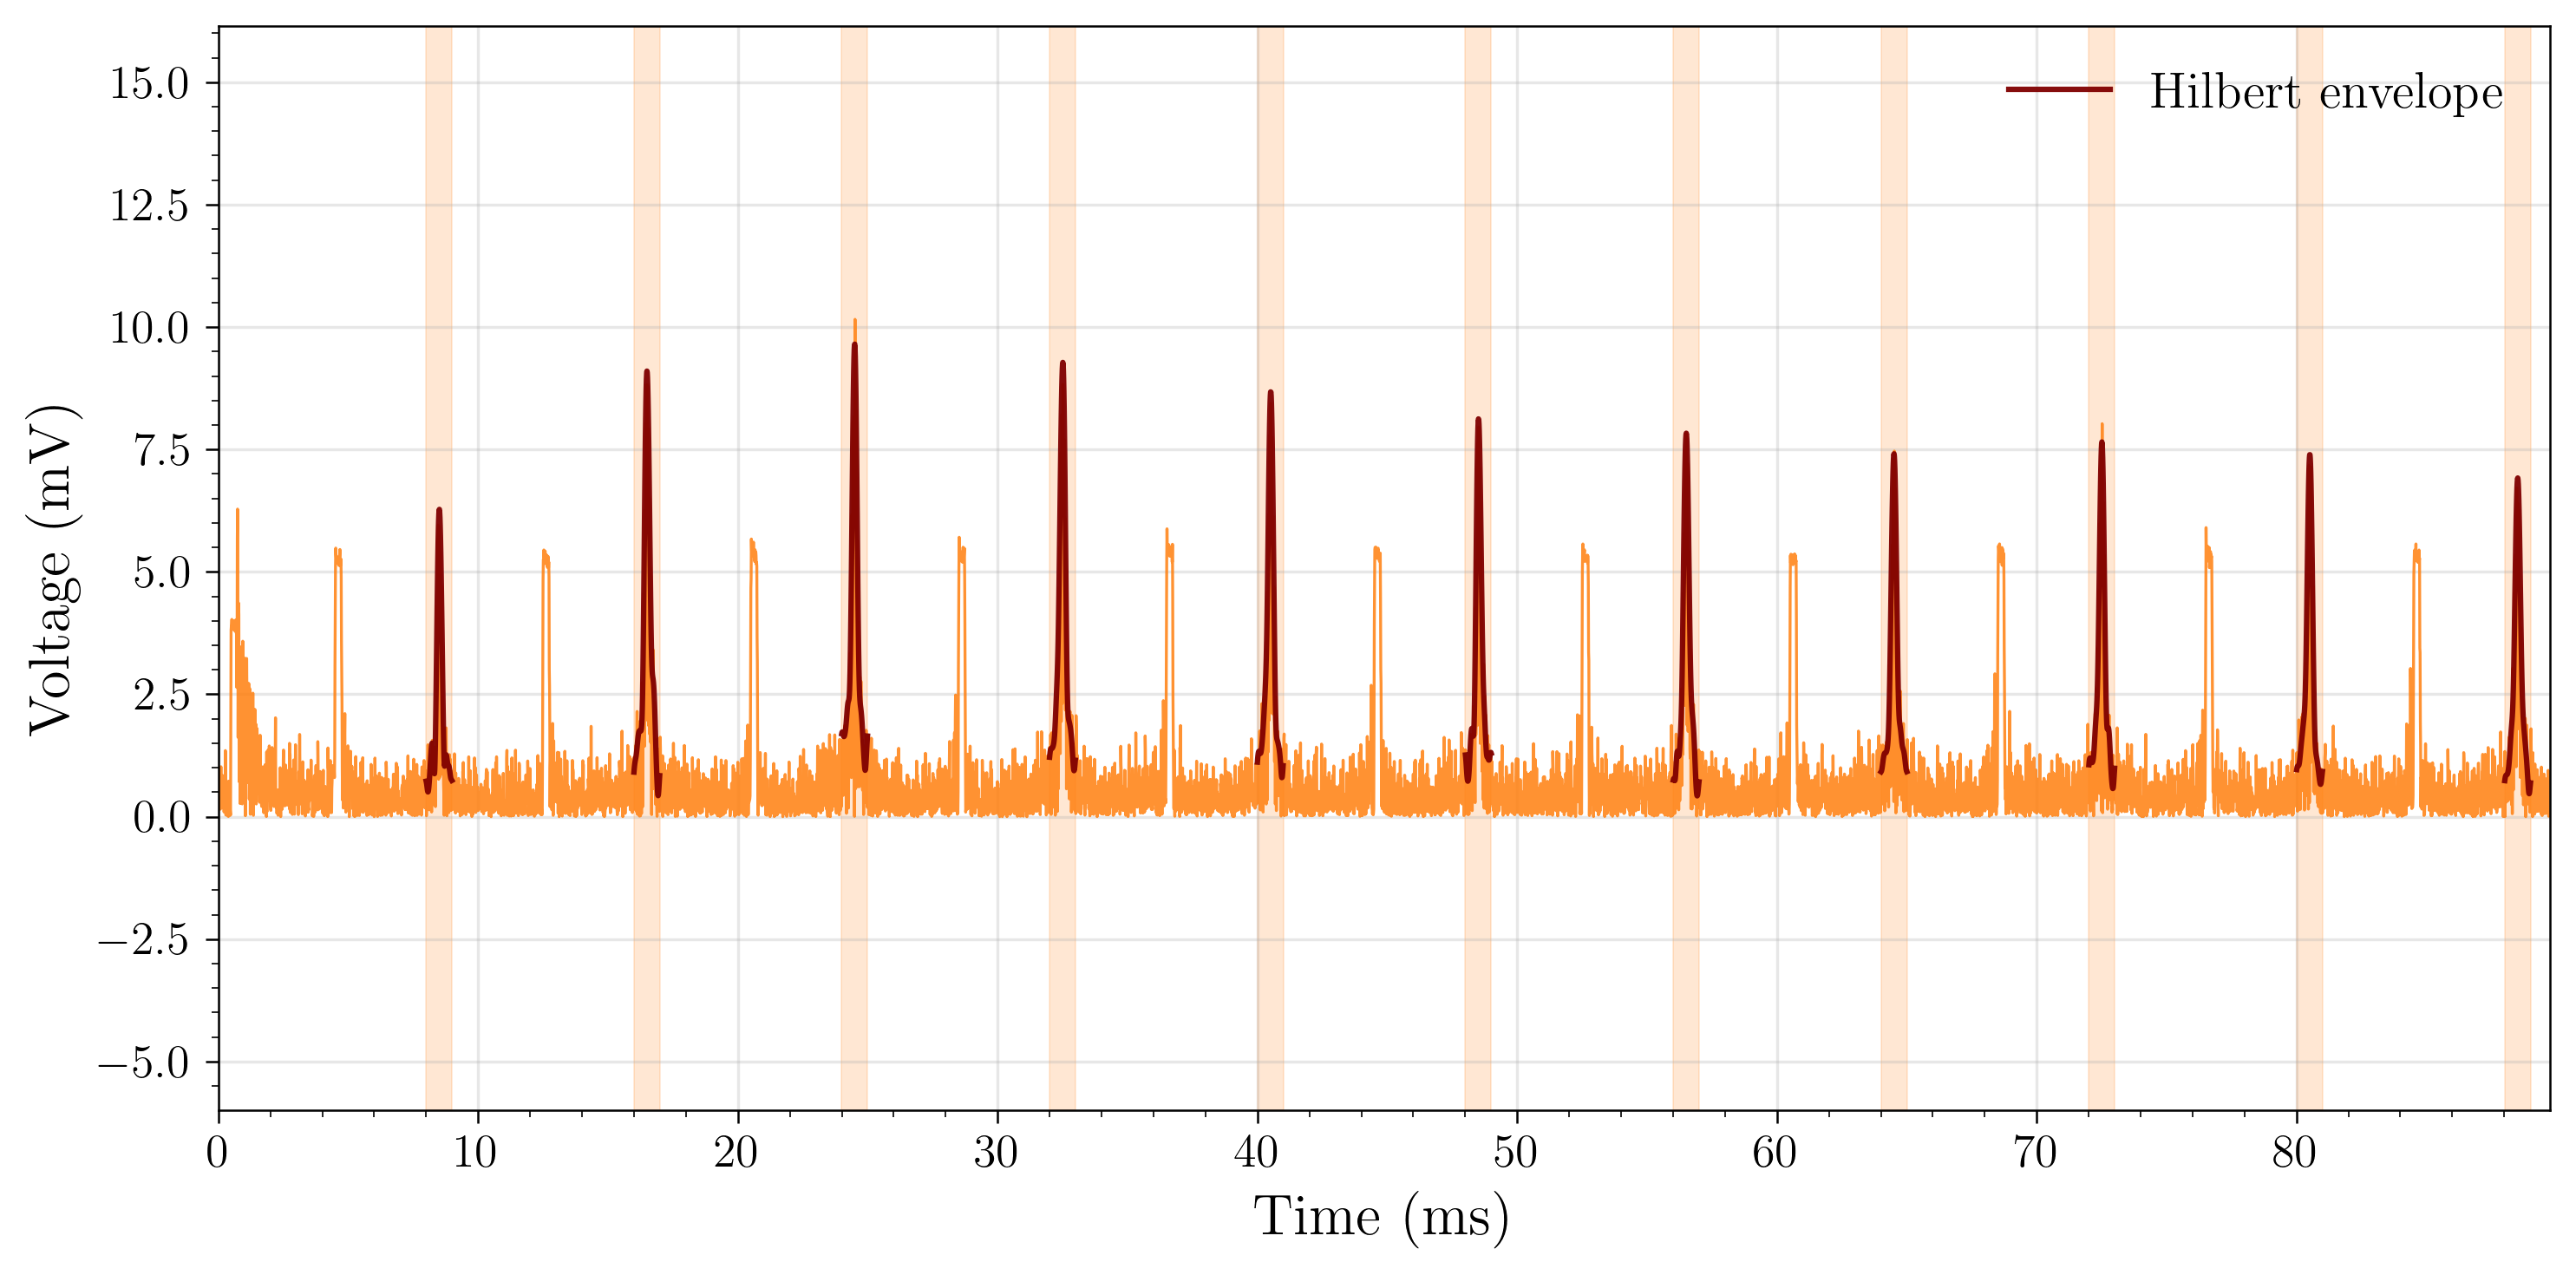

Lorentzian fit succeeded for 11 of 11 echoes


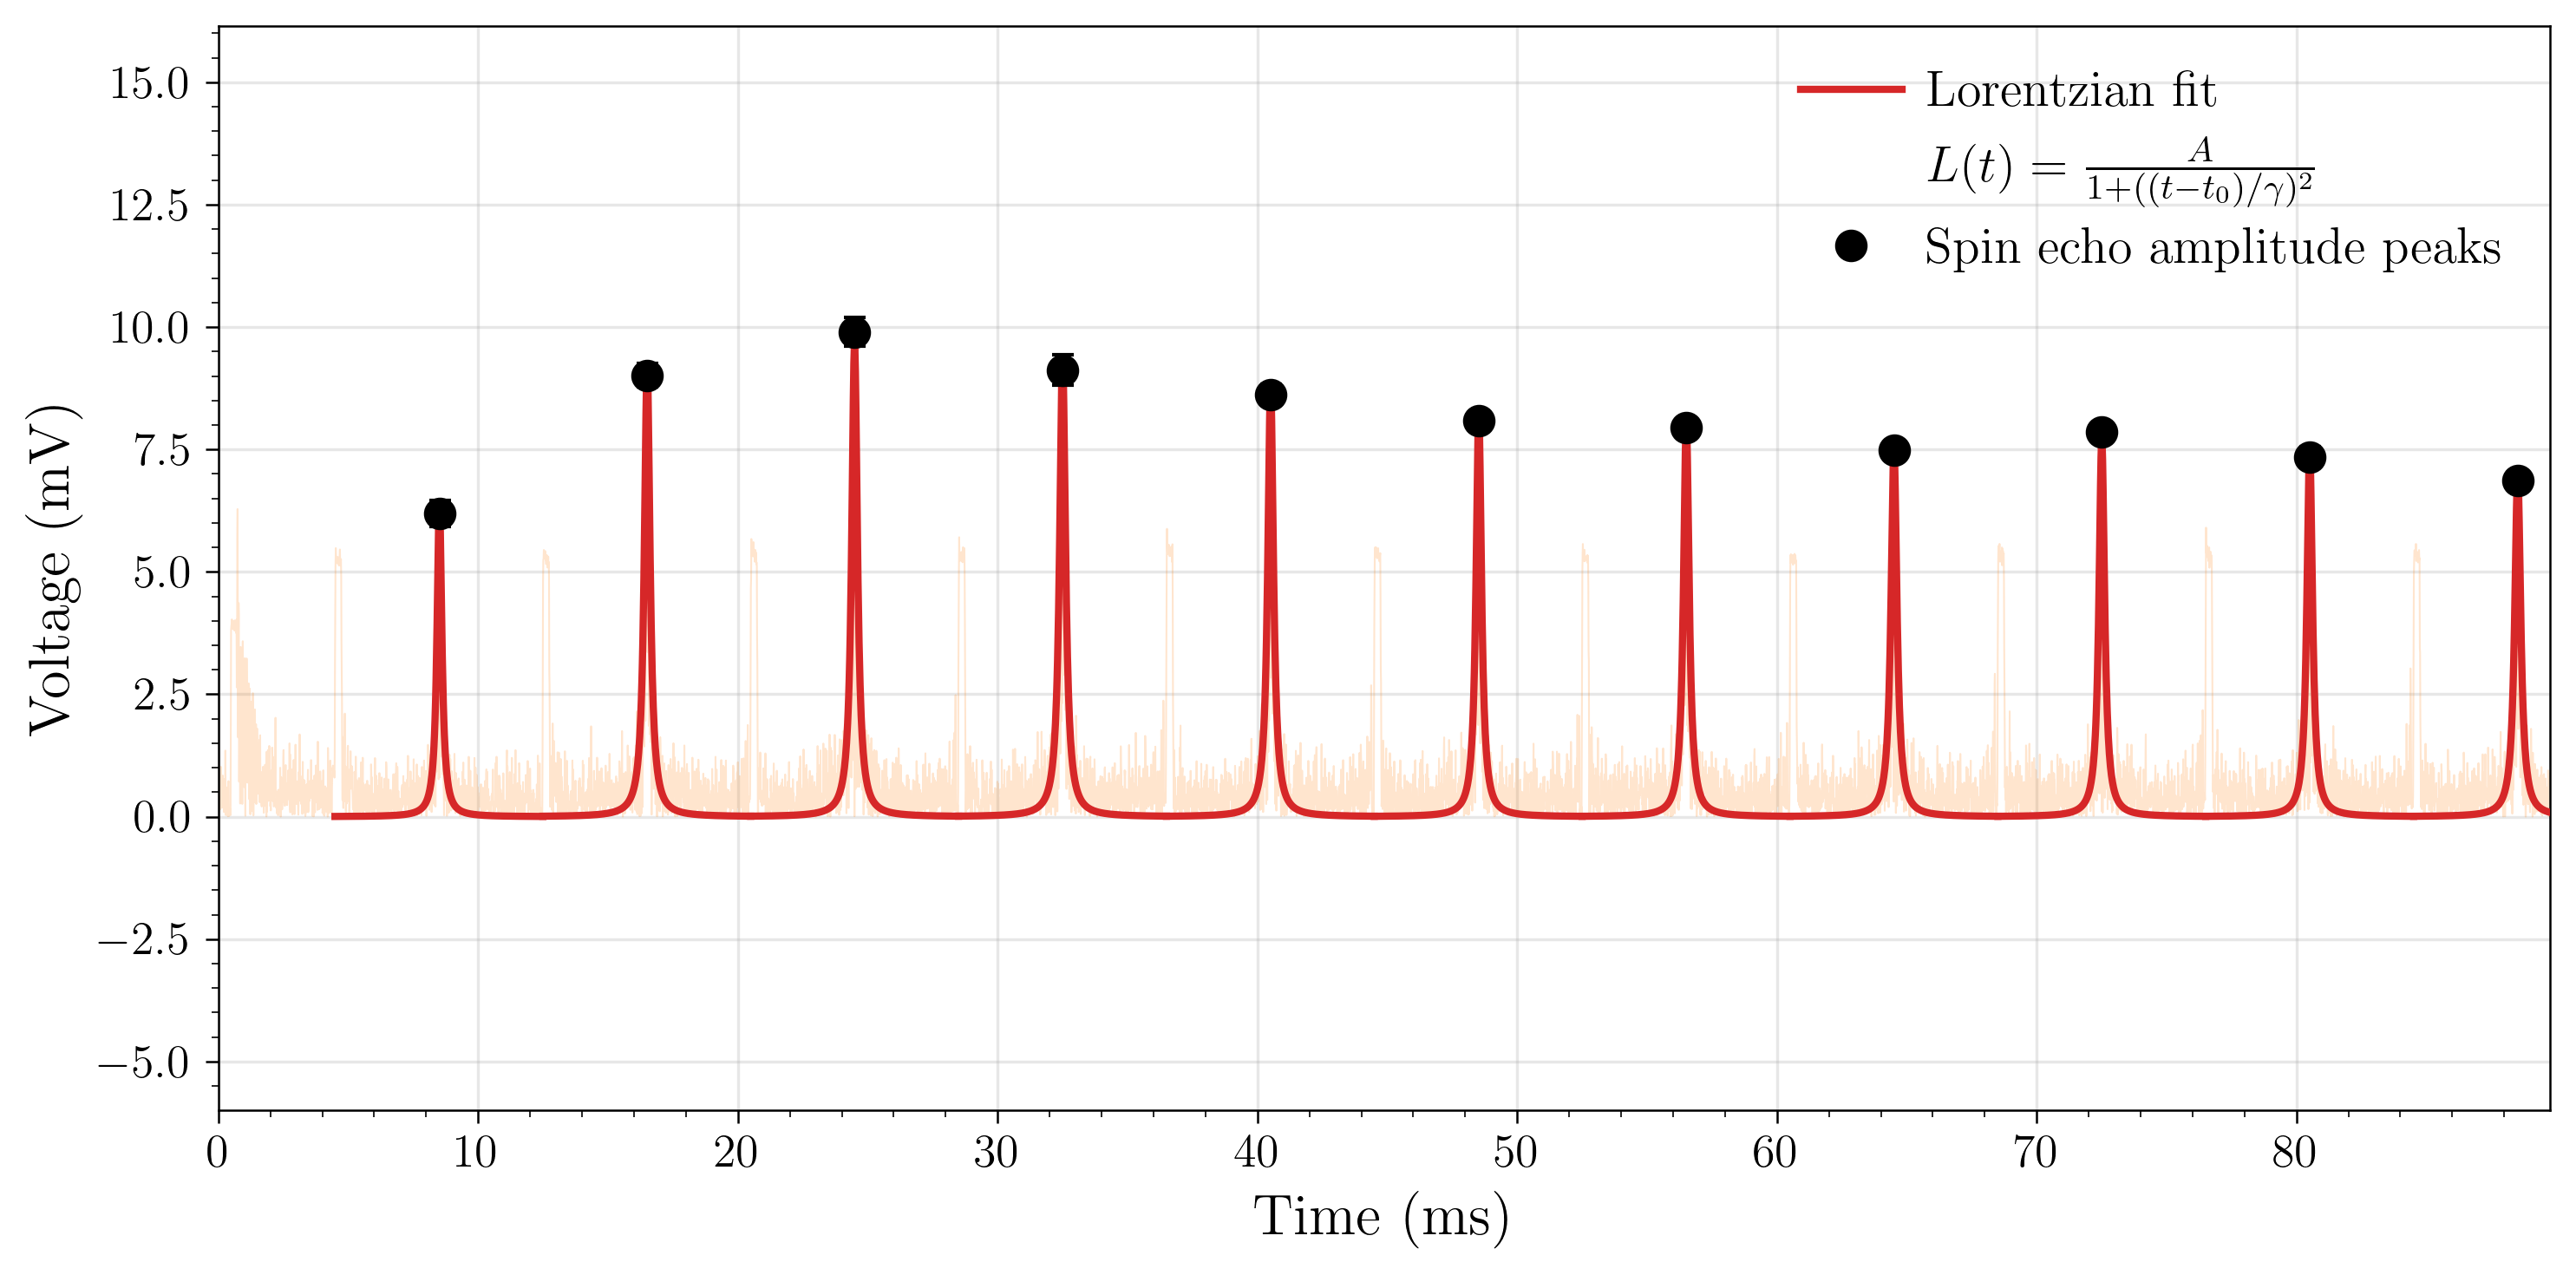

/tmp/ipykernel_12149/2003380282.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


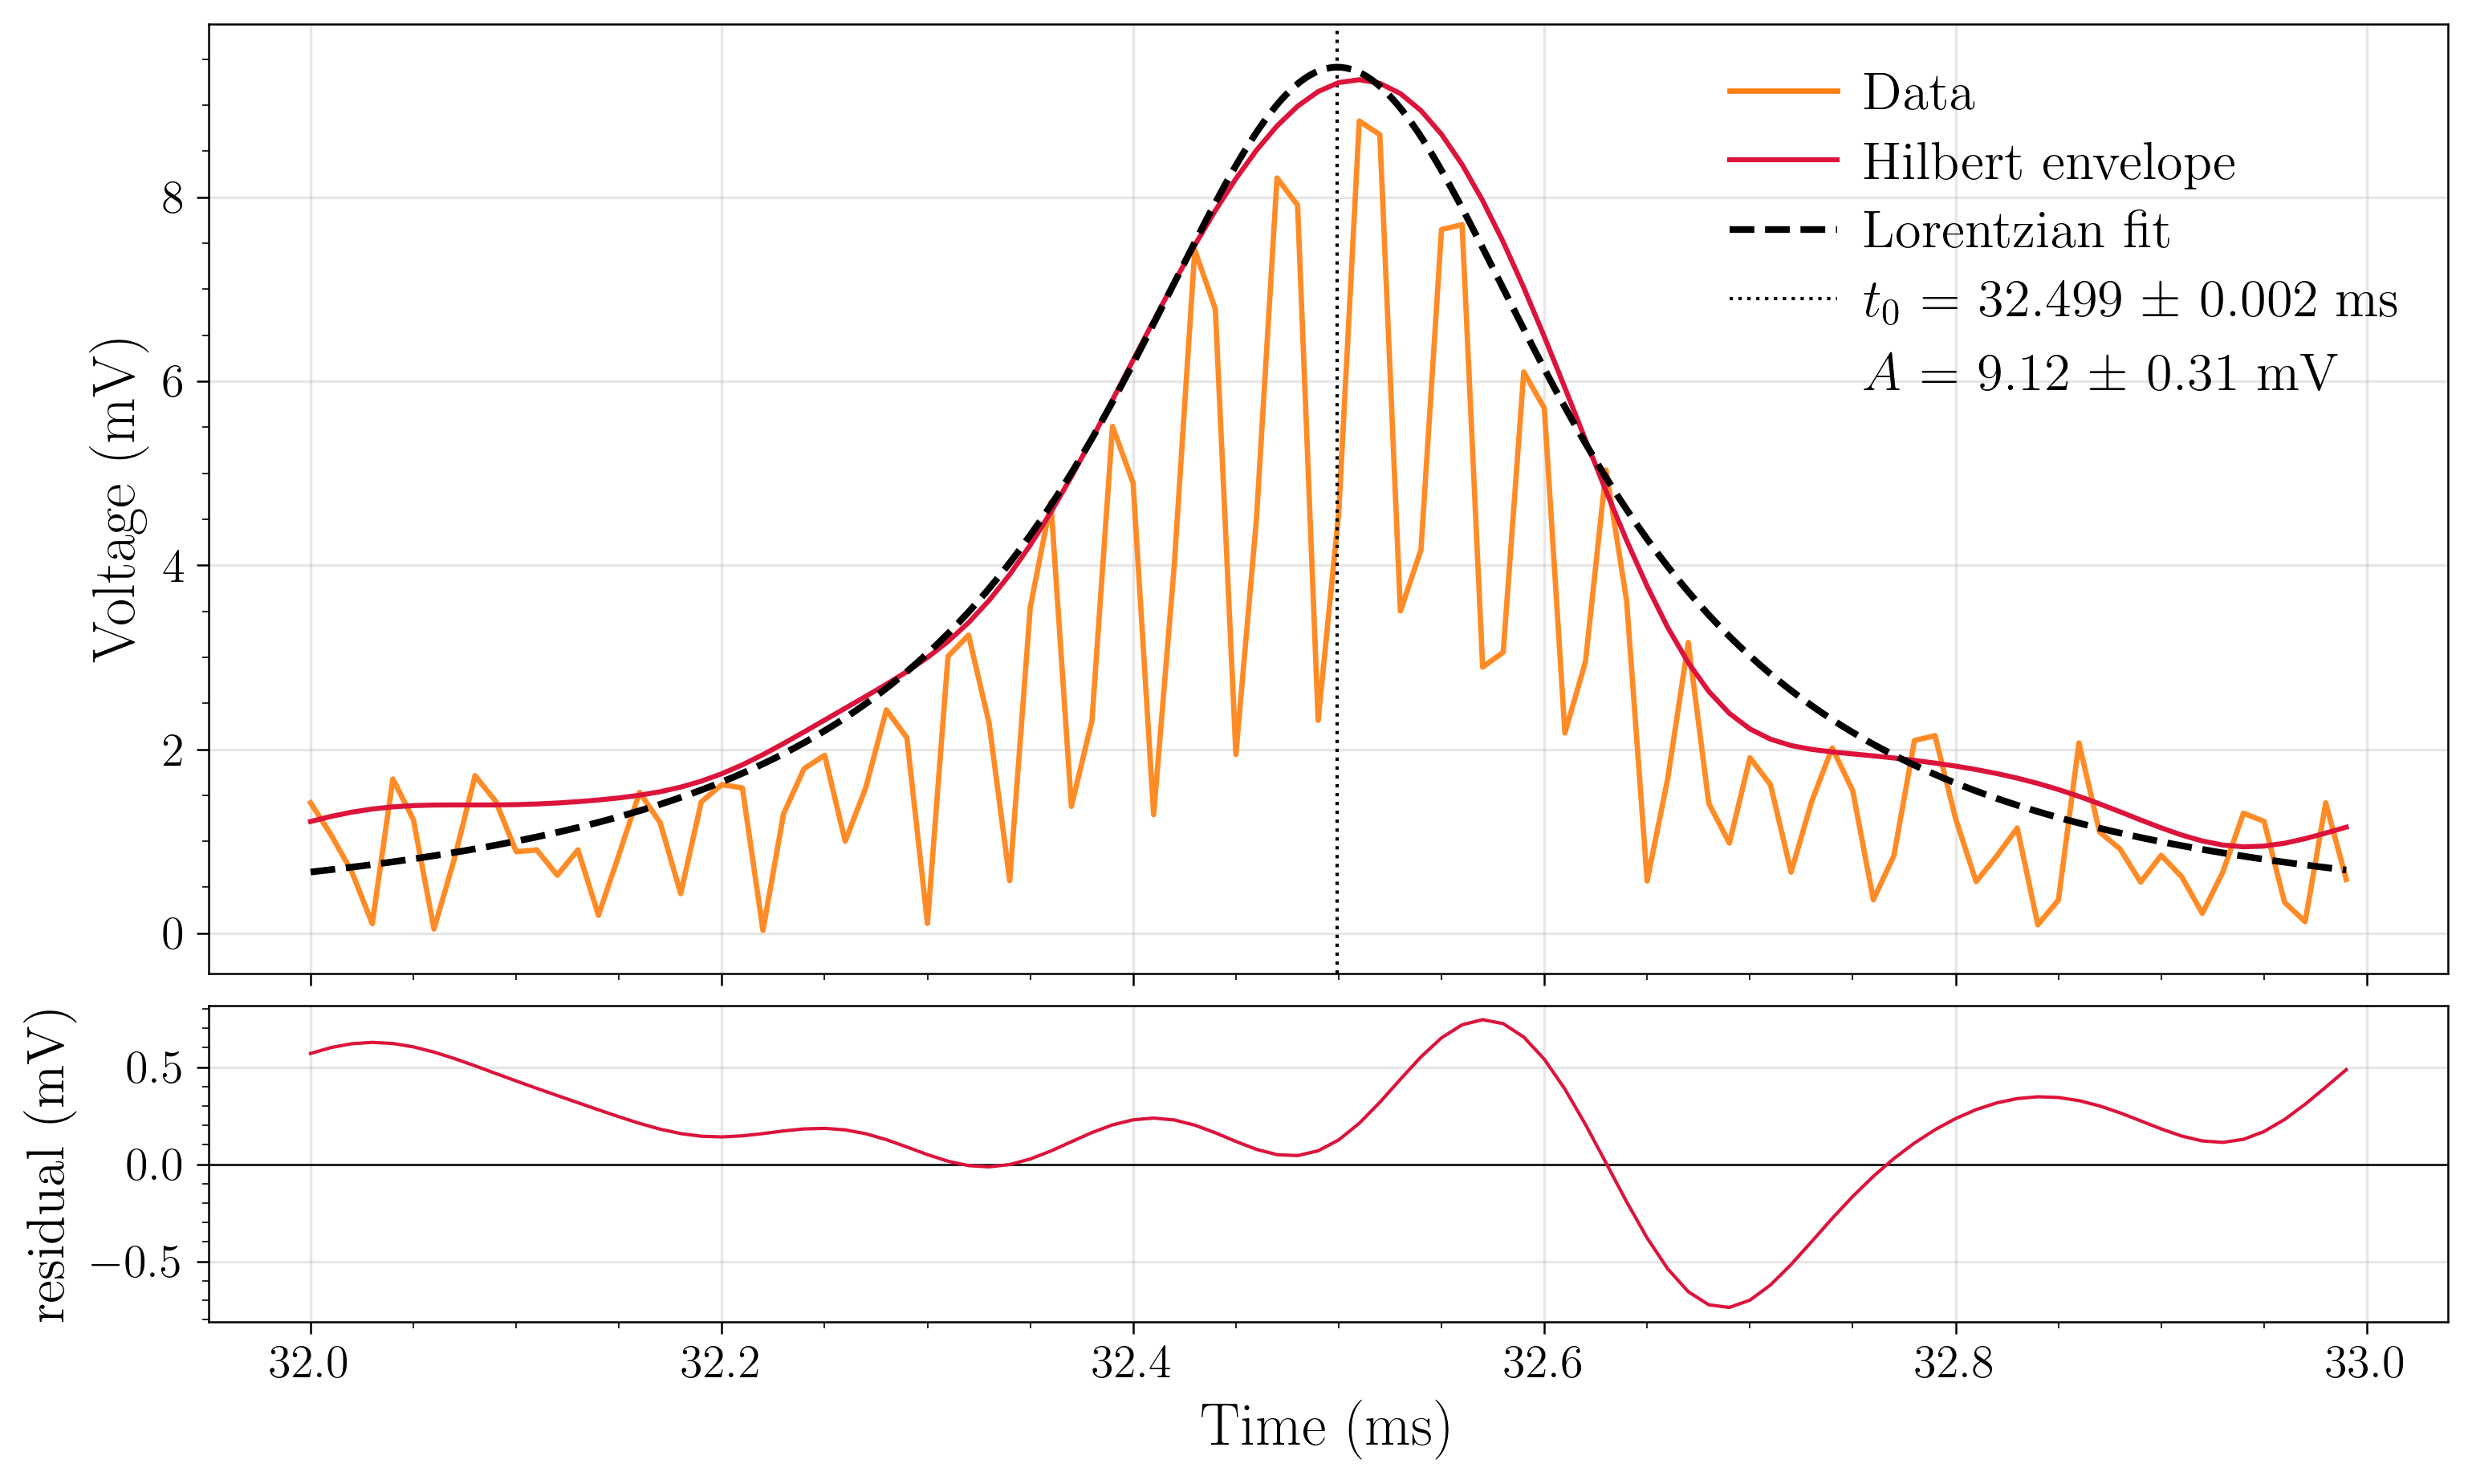

In [2]:
# --- Step 2a (new): |CH2| + estimated echo bands + Hilbert envelopes.
# Same axis box as Step 0/1 for clean PowerPoint cross-fading.
if USE_LORENTZIAN:
    fig, ax_a = plt.subplots(figsize=(10, 5))
    ax_a.plot(t * 1e3, np.abs(ch2) * 1e3, color='tab:orange',
              lw=0.8, alpha=0.85)
    for te in echo_times:
        ax_a.axvspan((te - window_s) * 1e3, (te + window_s) * 1e3,
                     color='tab:orange', alpha=0.18)
    for te in echo_times:
        m = (t >= te - window_s) & (t <= te + window_s)
        if m.sum() < 8:
            continue
        r_ = fit_lorentzian_to_window(t[m], ch2[m], c_fixed=c_fixed_ex)
        if r_ is None:
            continue
        ax_a.plot(r_['tp'] * 1e3, r_['yp'] * 1e3, color='maroon',
                  lw=1.5, alpha=0.95, zorder=5,
                  label='Hilbert envelope' if 'Hilbert envelope' not
                  in [h.get_label() for h in ax_a.get_lines()] else None)
    try:
        ax_a.set_xlim(_xlim_anim); ax_a.set_ylim(_ylim_anim_abs)
    except NameError:
        pass
    ax_a.set_xlabel('Time (ms)', fontsize=16)
    ax_a.set_ylabel('Voltage (mV)', fontsize=16)
    ax_a.tick_params(labelsize=13)
    ax_a.grid(True, alpha=0.3)
    ax_a.legend(loc='upper right', fontsize=14)
    plt.tight_layout()
    fig.savefig(os.path.join(STEP_FIG_DIR, 'step2a_hilbert.png'), dpi=150, bbox_inches='tight')
    plt.show()

# --- Step 2b: envelope hidden, only Lorentzian fits stand out.
fig, ax = plt.subplots(figsize=(10, 5))

if USE_LORENTZIAN:
    abs_ch2 = np.abs(ch2)
    ax.plot(t * 1e3, abs_ch2 * 1e3, color='tab:orange', lw=0.5, alpha=0.20,
            label='$|$CH2$|$ (AC-coupled)')

    n_fits = 0
    lorentz_results = {}  # echo index → fit dict (for the zoom panel below)
    for i, te in enumerate(echo_times):
        m = (t >= te - window_s) & (t <= te + window_s)
        if m.sum() < 8:
            continue
        r = fit_lorentzian_to_window(t[m], ch2[m], c_fixed=c_fixed_ex)
        if r is None:
            continue
        n_fits += 1
        lorentz_results[i] = r

    # Lorentzian curves get extended halfway to neighboring echoes
    # so each fit's curve spans its full echo-to-echo region.
    fit_curve_label_done = False
    for i, te in enumerate(echo_times):
        if i not in lorentz_results:
            continue
        r = lorentz_results[i]
        prev_te = echo_times[i - 1] if i > 0 else 2 * te - echo_times[i + 1]
        next_te = (echo_times[i + 1] if i + 1 < len(echo_times)
                   else 2 * te - echo_times[i - 1])
        t_left  = max(t.min(), 0.5 * (prev_te + te))
        t_right = min(t.max(), 0.5 * (te + next_te))
        t_curve = np.linspace(t_left, t_right, 400)
        ax.plot(t_curve * 1e3,
                lorentzian(t_curve, r['amp_raw'], r['t0'], r['gamma']) * 1e3,
                color='tab:red', lw=2.0, zorder=6,
                label='Lorentzian fit' if not fit_curve_label_done else None)
        fit_curve_label_done = True

    # Mark each Lorentzian's peak (t0, A) so the decay envelope is
    # readable at a glance. Show both the t0 horizontal uncertainty
    # and the corrected amp vertical uncertainty.
    peak_t   = np.array([r['t0']      for r in lorentz_results.values()])
    peak_y   = np.array([r['amp']     for r in lorentz_results.values()])
    peak_xe  = np.array([r['t0_err']  for r in lorentz_results.values()])
    peak_ye  = np.array([r['amp_err'] for r in lorentz_results.values()])
    if len(peak_t):
        ax.errorbar(peak_t * 1e3, peak_y * 1e3,
                    xerr=peak_xe * 1e3, yerr=peak_ye * 1e3,
                    fmt='o', ms=8, color='black', ecolor='black',
                    elinewidth=1.0, capsize=3, zorder=7,
                    label='Spin echo amplitude peaks')

    try:
        ax.set_xlim(_xlim_anim); ax.set_ylim(_ylim_anim_abs)
    except NameError:
        pass

    ax.set_ylabel('Voltage (mV)', fontsize=16)
    title = (f'Step 2: Hilbert envelope $|H[\\mathrm{{CH2}}]|$ + '
             f'Lorentzian fit per echo')
    print(f"Lorentzian fit succeeded for {n_fits} of {len(echo_times)} echoes")
else:
    pos_t, pos_y, neg_t, neg_y = [], [], [], []
    for te in echo_times:
        mask = (t >= te - window_s) & (t <= te + window_s)
        yi = ch2[mask]; ti = t[mask]
        if len(yi) < 2 * N_EXTREMA:
            continue
        order = np.argsort(yi)
        pos_t.extend(ti[order[-N_EXTREMA:]]); pos_y.extend(yi[order[-N_EXTREMA:]])
        neg_t.extend(ti[order[:N_EXTREMA]]);  neg_y.extend(yi[order[:N_EXTREMA]])
    pos_t, pos_y = np.array(pos_t), np.array(pos_y)
    neg_t, neg_y = np.array(neg_t), np.array(neg_y)

    ax.plot(t * 1e3, ch2, color='tab:orange', lw=0.9, label='CH2 (AC-coupled)')
    for i, te in enumerate(echo_times):
        ax.axvspan((te - window_s) * 1e3, (te + window_s) * 1e3,
                   color='tab:orange', alpha=0.12,
                   label=f'echo $\\pm$ {window_s*1e3:.0f} ms' if i == 0 else None)
    for i, te in enumerate(echo_times):
        ax.axvline(te * 1e3, color='k', ls='--', lw=0.7, alpha=0.5,
                   label='estimated echo' if i == 0 else None)
    ax.scatter(pos_t * 1e3, pos_y, s=80, c='crimson', zorder=5,
               edgecolor='black', lw=0.5,
               label=f'top {N_EXTREMA} max per echo')
    ax.scatter(neg_t * 1e3, neg_y, s=80, c='royalblue', zorder=5,
               edgecolor='black', lw=0.5,
               label=f'top {N_EXTREMA} min per echo')

    ax.set_ylabel('Voltage (V, AC-coupled)')
    title = (f'Step 2: extract {2 * N_EXTREMA}-point extrema from CH2 '
             f'within each echo band')
    print(f"Picked {len(pos_t)} pos + {len(neg_t)} neg extrema "
          f"({2 * N_EXTREMA} per echo across {len(echo_times)} echoes)")

ax.set_xlabel('Time (ms)', fontsize=16)
ax.tick_params(labelsize=13)
ax.grid(True, alpha=0.3)
# Build legend with the Lorentzian equation as a no-handle
# continuation row beneath the 'Lorentzian fit' entry.
from matplotlib.lines import Line2D as _Line2D
_legend_handles = [
    _Line2D([], [], color='tab:red', lw=2.0, label='Lorentzian fit'),
    _Line2D([], [], color='none',
            label=r'$L(t) = \frac{A}{1 + ((t-t_0)/\gamma)^2}$'),
    _Line2D([], [], marker='o', ms=8, linestyle='', color='black',
            label='Spin echo amplitude peaks'),
]
ax.legend(handles=_legend_handles, loc='upper right', fontsize=14,
          handletextpad=0.5, labelspacing=0.4)
plt.tight_layout()
fig.savefig(os.path.join(STEP_FIG_DIR, 'step2b_lorentzian.png'), dpi=150, bbox_inches='tight')
plt.show()


# --- Step 2 (zoom): one echo blown up so the Lorentzian fit quality is
# visible. Picks an early-decay echo with a successful fit, by default the
# 4th echo (index 3) where the signal is still strong but past the
# excluded n_skip transient.
if USE_LORENTZIAN and lorentz_results:
    zoom_idx = 3 if 3 in lorentz_results else min(lorentz_results)
    r = lorentz_results[zoom_idx]
    te = echo_times[zoom_idx]

    fig, (ax_top, ax_res) = plt.subplots(
        2, 1, figsize=(12, 7), sharex=True,
        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

    m = (t >= te - window_s) & (t <= te + window_s)
    t_band = t[m]; abs_band = np.abs(ch2[m])

    t_fine = np.linspace(t_band.min(), t_band.max(), 400)
    y_fine = lorentzian(t_fine, r['amp_raw'], r['t0'], r['gamma'])

    ax_top.plot(t_band * 1e3, abs_band * 1e3, color='tab:orange',
                lw=1.6, alpha=0.9)
    ax_top.plot(r['tp'] * 1e3, r['yp'] * 1e3, color='crimson',
                lw=1.5, zorder=4)
    ax_top.plot(t_fine * 1e3, y_fine * 1e3, color='black', lw=2.0,
                ls='--', zorder=5)
    ax_top.axvline(r['t0'] * 1e3, color='k', ls=':', lw=1.0)

    # Legend built from proxy handles so A sits on its own row below t_0.
    from matplotlib.lines import Line2D as _Line2D
    _zoom_legend = [
        _Line2D([], [], color='tab:orange', lw=1.6, label='Data'),
        _Line2D([], [], color='crimson', lw=1.5, label='Hilbert envelope'),
        _Line2D([], [], color='black', lw=2.0, ls='--', label='Lorentzian fit'),
        _Line2D([], [], color='k', ls=':', lw=1.0,
                label=(r'$t_0$ = ' +
                       f"{r['t0']*1e3:.3f} $\\pm$ {r['t0_err']*1e3:.3f} ms")),
        _Line2D([], [], color='none',
                label=(r'$A$ = ' +
                       f"{r['amp']*1e3:.2f} $\\pm$ {r['amp_err']*1e3:.2f} mV")),
    ]

    ax_top.set_ylabel('Voltage (mV)', fontsize=18)
    ax_top.tick_params(labelsize=14)
    ax_top.grid(True, alpha=0.3)
    ax_top.legend(handles=_zoom_legend, loc='upper right', fontsize=16,
                  handletextpad=0.5, labelspacing=0.4)

    # Residuals = envelope − fit at the same t samples.
    y_pred = lorentzian(r['tp'], r['amp'], r['t0'], r['gamma'])
    resid = (r['yp'] - y_pred) * 1e3
    ax_res.axhline(0, color='k', lw=0.6)
    ax_res.plot(r['tp'] * 1e3, resid, color='crimson', lw=1.0)
    ax_res.set_ylabel('residual (mV)', fontsize=16)
    ax_res.set_xlabel('Time (ms)', fontsize=18)
    ax_res.tick_params(labelsize=14)
    ax_res.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(os.path.join(STEP_FIG_DIR, 'step2_zoom.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

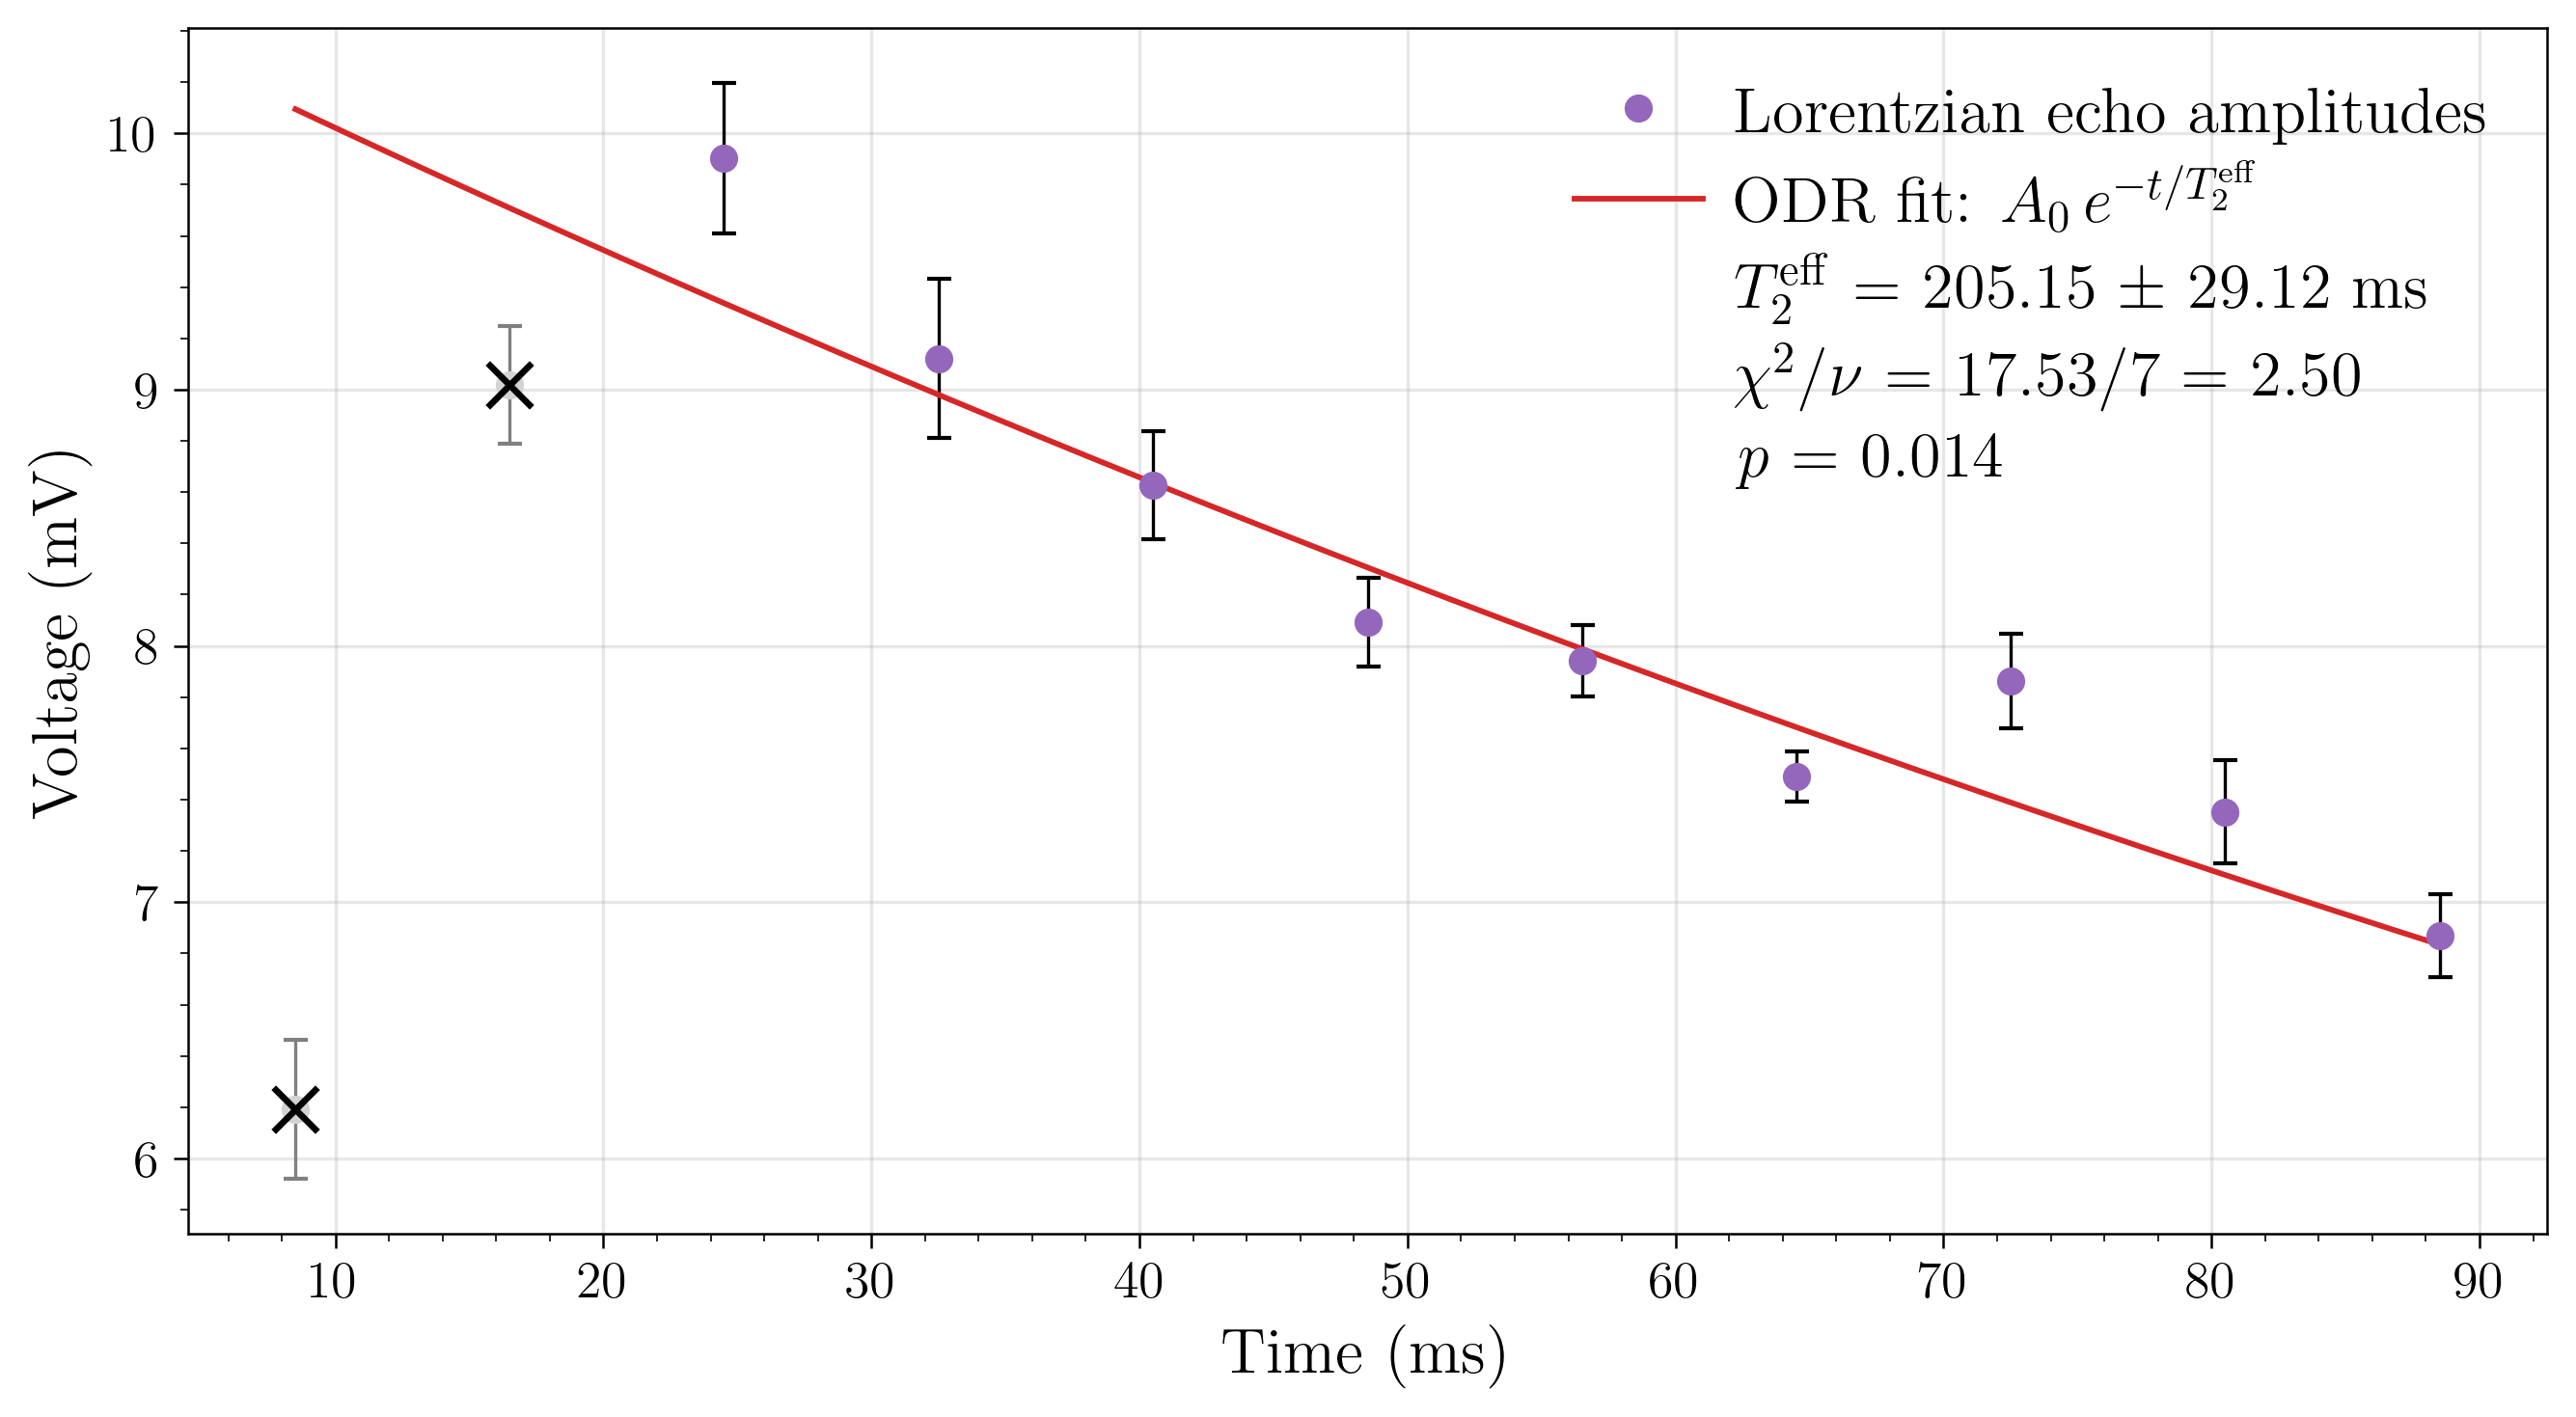

Fit on 9 points (skipped first 2; method: Lorentzian, N=16)
  A0 = 10.5217 ± 0.4509 mV
  T2 = 205.1453 ± 29.1189 ms
  χ²/ν = 17.534/7 = 2.505,  p = 0.0143


In [3]:
from scipy import odr
from scipy.stats import chi2 as chi2_dist

# Step 3: per-echo amplitude (and uncertainty) from compute_echo_amplitude;
# ODR-fit A0 * exp(-t / T2). USE_LORENTZIAN / N_EXTREMA are set in cell 0.

echo_t_kept, amp_mean, amp_unc, t_err = [], [], [], []
for te in echo_times:
    mask = (t >= te - window_s) & (t <= te + window_s)
    res = compute_echo_amplitude(t[mask], ch2[mask], c_fixed=c_fixed_ex)
    if res is None:
        continue
    et_v, am_v, ae_v, te_v = res
    echo_t_kept.append(et_v)
    amp_mean.append(am_v)
    amp_unc.append(ae_v)
    t_err.append(te_v)

echo_t_kept = np.array(echo_t_kept)
amp_mean    = np.array(amp_mean)
amp_unc     = np.array(amp_unc)
t_err       = np.array(t_err)

# Drop the first few points (early-time transient / pulse-bleed-through);
# still plot them with X overlay.
n_skip = 2
fit_t      = echo_t_kept[n_skip:]
fit_amp    = amp_mean[n_skip:]
fit_sem    = amp_unc[n_skip:]
fit_t_err  = t_err[n_skip:]

def exp_decay_model(beta, t):
    return beta[0] * np.exp(-t / beta[1])

model = odr.Model(exp_decay_model)
sx = np.where(fit_t_err > 0, fit_t_err, np.min(np.diff(t)))
data = odr.RealData(fit_t, fit_amp, sx=sx, sy=fit_sem)
beta0 = [fit_amp[0], (fit_t[-1] - fit_t[0]) / 2]
out = odr.ODR(data, model, beta0=beta0).run()

A0_fit, T2_fit = out.beta
A0_err, T2_err = out.sd_beta
chi2_val   = out.sum_square
dof        = len(fit_t) - 2
chi2_red   = chi2_val / dof
p_value    = chi2_dist.sf(chi2_val, df=dof)

t_fine = np.linspace(echo_t_kept[0], echo_t_kept[-1], 400)
method_lbl = (f'Lorentzian, N={N_EXTREMA}'
              if USE_LORENTZIAN else f'{2 * N_EXTREMA}-pt extrema')

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(echo_t_kept[:n_skip] * 1e3, amp_mean[:n_skip] * 1e3,
            xerr=t_err[:n_skip] * 1e3, yerr=amp_unc[:n_skip] * 1e3,
            fmt='o', ms=6, color='lightgray', ecolor='gray',
            elinewidth=0.8, capsize=3)
ax.scatter(echo_t_kept[:n_skip] * 1e3, amp_mean[:n_skip] * 1e3,
           marker='x', s=120, c='black', lw=1.6, zorder=6)
ax.errorbar(fit_t * 1e3, fit_amp * 1e3, xerr=fit_t_err * 1e3, yerr=fit_sem * 1e3,
            fmt='o', ms=6, color='tab:purple', ecolor='black',
            elinewidth=0.8, capsize=3)
ax.plot(t_fine * 1e3, exp_decay_model(out.beta, t_fine) * 1e3,
        '-', color='tab:red', lw=1.4)

# Build the legend with proxy handles so the red line marker sits
# next to the 'ODR fit: ...' line specifically; the T_2 / chi / p
# lines are continuation text with invisible handles.
from matplotlib.lines import Line2D as _Line2D
_legend = [
    _Line2D([], [], color='tab:purple', marker='o', ms=6, linestyle='',
            label='Lorentzian echo amplitudes'),
    _Line2D([], [], color='tab:red', lw=1.4,
            label=r'ODR fit: $A_0\, e^{-t/T_2^{\mathrm{eff}}}$'),
    _Line2D([], [], color='none',
            label=(r'$T_2^{\mathrm{eff}}$ = ' + f'{T2_fit*1e3:.2f} $\\pm$ {T2_err*1e3:.2f} ms')),
    _Line2D([], [], color='none',
            label=f'$\\chi^2/\\nu$ = {chi2_val:.2f}/{dof} = {chi2_red:.2f}'),
    _Line2D([], [], color='none',
            label=f'$p$ = {p_value:.3f}'),
]

ax.set_xlabel('Time (ms)', fontsize=16)
ax.set_ylabel('Voltage (mV)', fontsize=16)
ax.tick_params(labelsize=13)
ax.grid(True, alpha=0.3)
ax.legend(handles=_legend, loc='upper right', fontsize=16,
          handletextpad=0.5, labelspacing=0.3)
plt.tight_layout()
fig.savefig(os.path.join(STEP_FIG_DIR, 'step3_t2fit.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Fit on {len(fit_t)} points (skipped first {n_skip}; method: {method_lbl})")
print(f"  A0 = {A0_fit*1e3:.4f} ± {A0_err*1e3:.4f} mV")
print(f"  T2 = {T2_fit*1e3:.4f} ± {T2_err*1e3:.4f} ms")
print(f"  χ²/ν = {chi2_val:.3f}/{dof} = {chi2_red:.3f},  p = {p_value:.4f}")

<>:374: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:560: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:374: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:560: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_12149/1501655272.py:374: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_ylabel('$T_2^{\mathrm{eff}}$ (ms)', fontsize=16)
/tmp/ipykernel_12149/1501655272.py:560: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. 

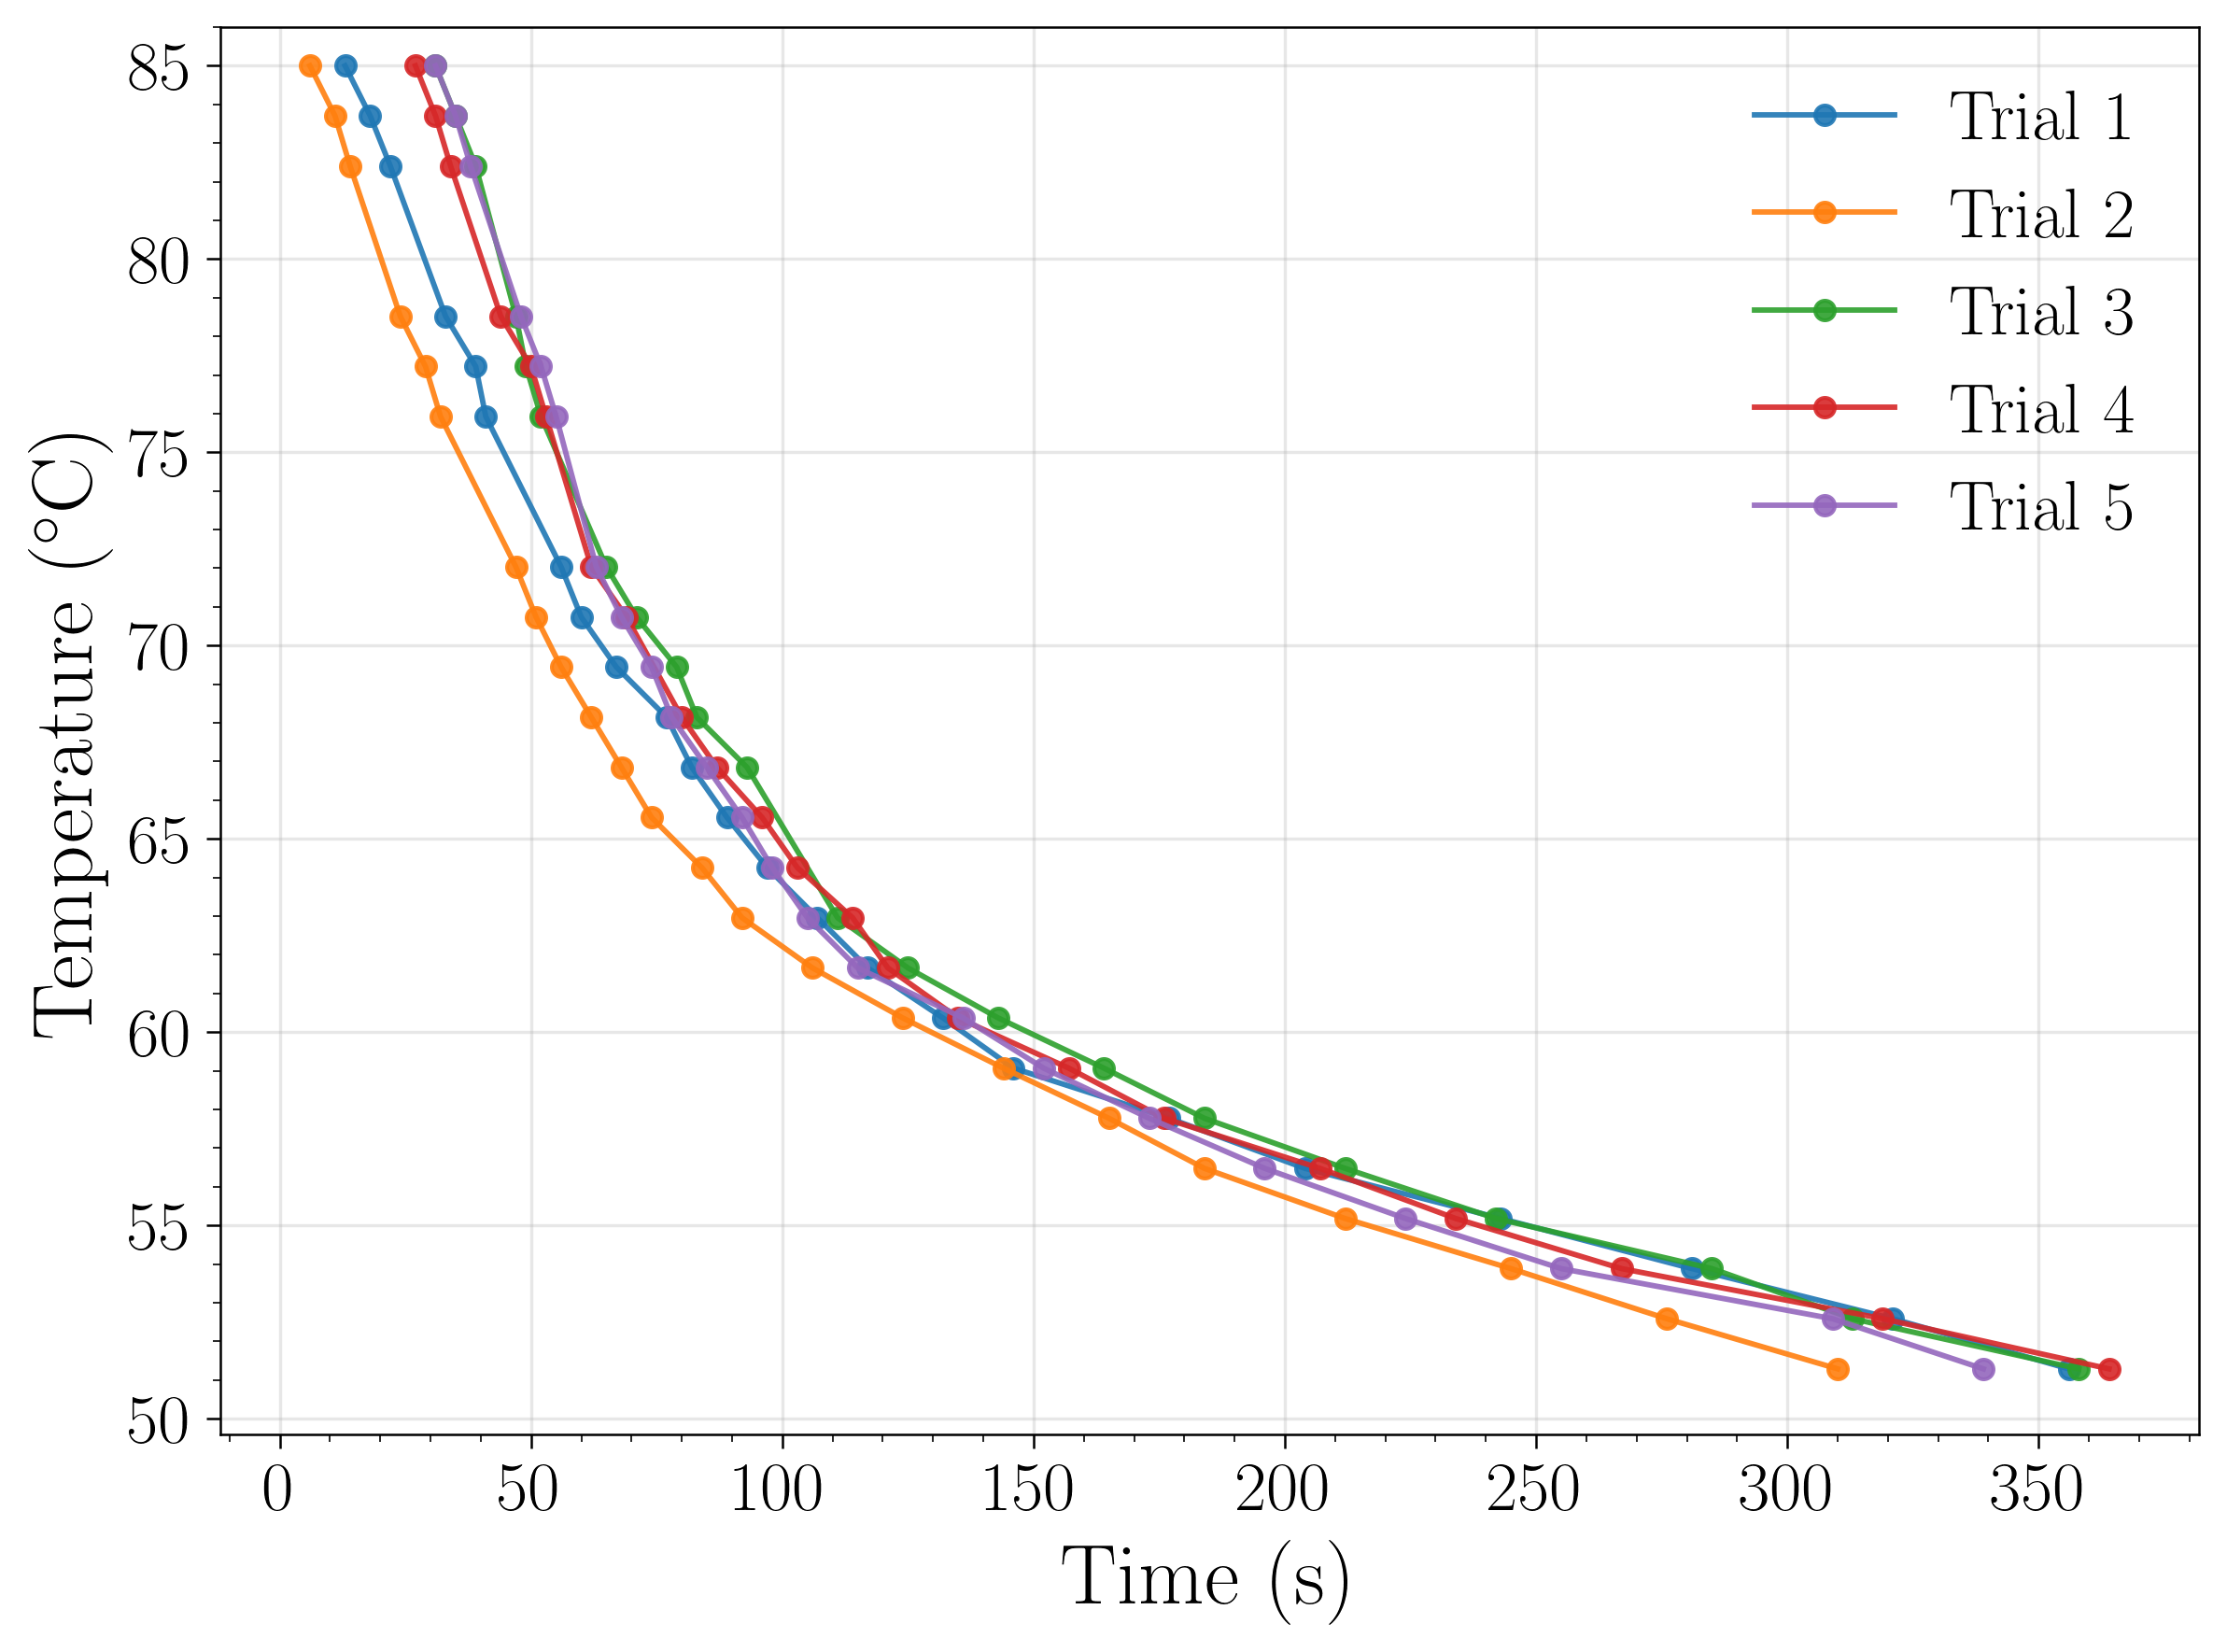

Method: Lorentzian, N=16
T_rec  T_corr   sigT   file  res  n_skip     T2 (ms)    sig_T2   chi2/nu        p
-------------------------------------------------------------------------------------
 54.0   53.19   0.81  0035   hi       3       84.07      2.98     0.063   0.9996
 55.0   53.93   1.07  0017   lo       3       71.23     13.96     0.436   0.8552
 55.0   54.35   0.65  0019   lo       2      107.03     16.44     0.361   0.9250
 57.5   56.14   1.36  0036   hi       3       96.68      5.37     0.305   0.9522
 60.0   58.84   1.16  0020   lo       2      129.22     10.92     0.228   0.9789


 62.5   60.53   1.97  0038   hi       3      113.34      6.26     0.377   0.9162
 65.0   63.66   1.34  0021   lo       2      194.49     16.56     0.520   0.8203
 65.0   63.74   1.26  0022   lo       3      123.85     11.04     0.991   0.4289
 66.0   63.45   2.55  0039   hi       4      154.36      7.12     0.077   0.9983
 67.5   66.34   1.16  0027   lo       3      177.69     15.61     0.513   0.7987
 68.5   66.42   2.08  0040   hi       4      147.09      2.31     0.041   0.9997


 70.0   68.70   1.30  0023   lo       3      147.26     20.31     2.917   0.0076
 71.2   69.46   1.74  0041   hi       3      187.91     13.22     0.317   0.9469
 72.5   70.62   1.88  0026   lo       3      160.28     11.02     2.016   0.0598
 73.7   71.93   1.77  0042   hi       4      173.90     10.14     0.191   0.9795
 75.0   73.65   1.35  0024   lo       4      155.48     23.22     1.371   0.2318


 76.2   74.20   2.00  0043   hi       5      179.88     11.18     0.093   0.9933
 77.5   75.77   1.73  0028   lo       4      141.45     23.59     7.680   0.0000
 78.5   76.80   1.70  0044   hi       3      244.57     25.40     0.267   0.9666
 80.0   78.72   1.28  0025   lo       2      202.23     25.78     3.548   0.0008
 82.5   80.85   1.65  0029   lo       3      202.90     21.03     3.181   0.0040
 85.0   83.03   1.98  0045   hi       3      226.30     22.91     0.158   0.9930


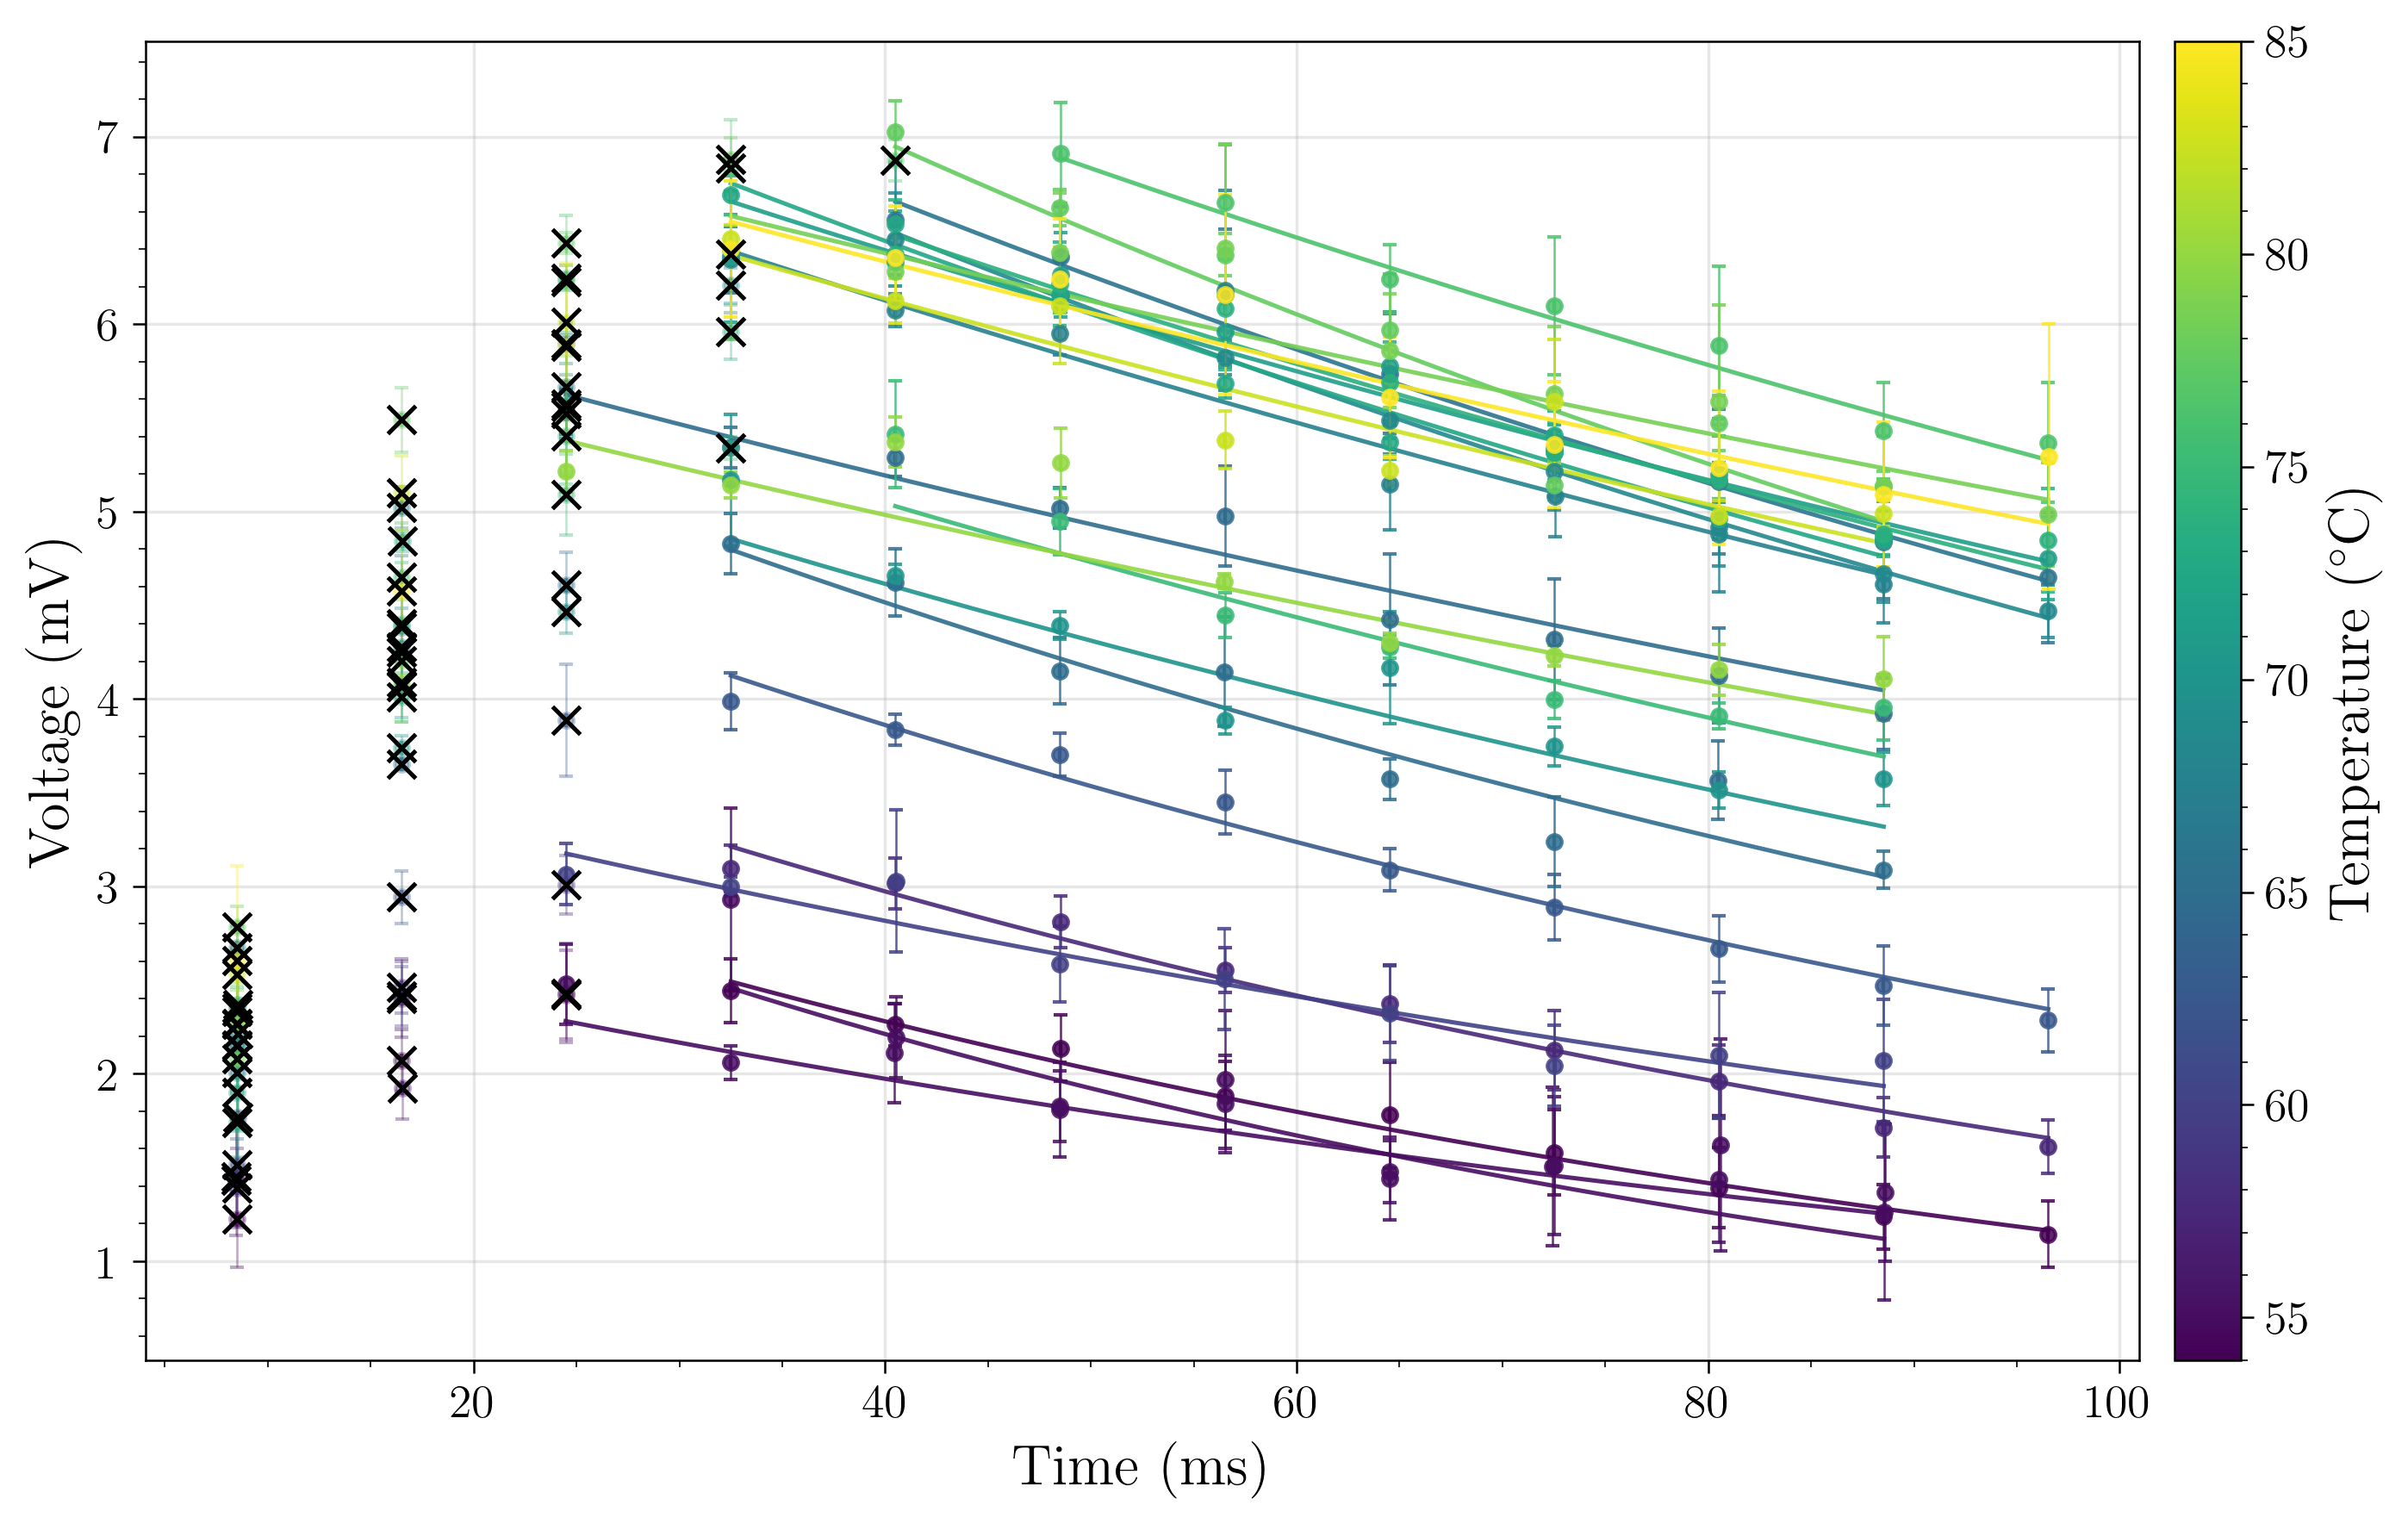

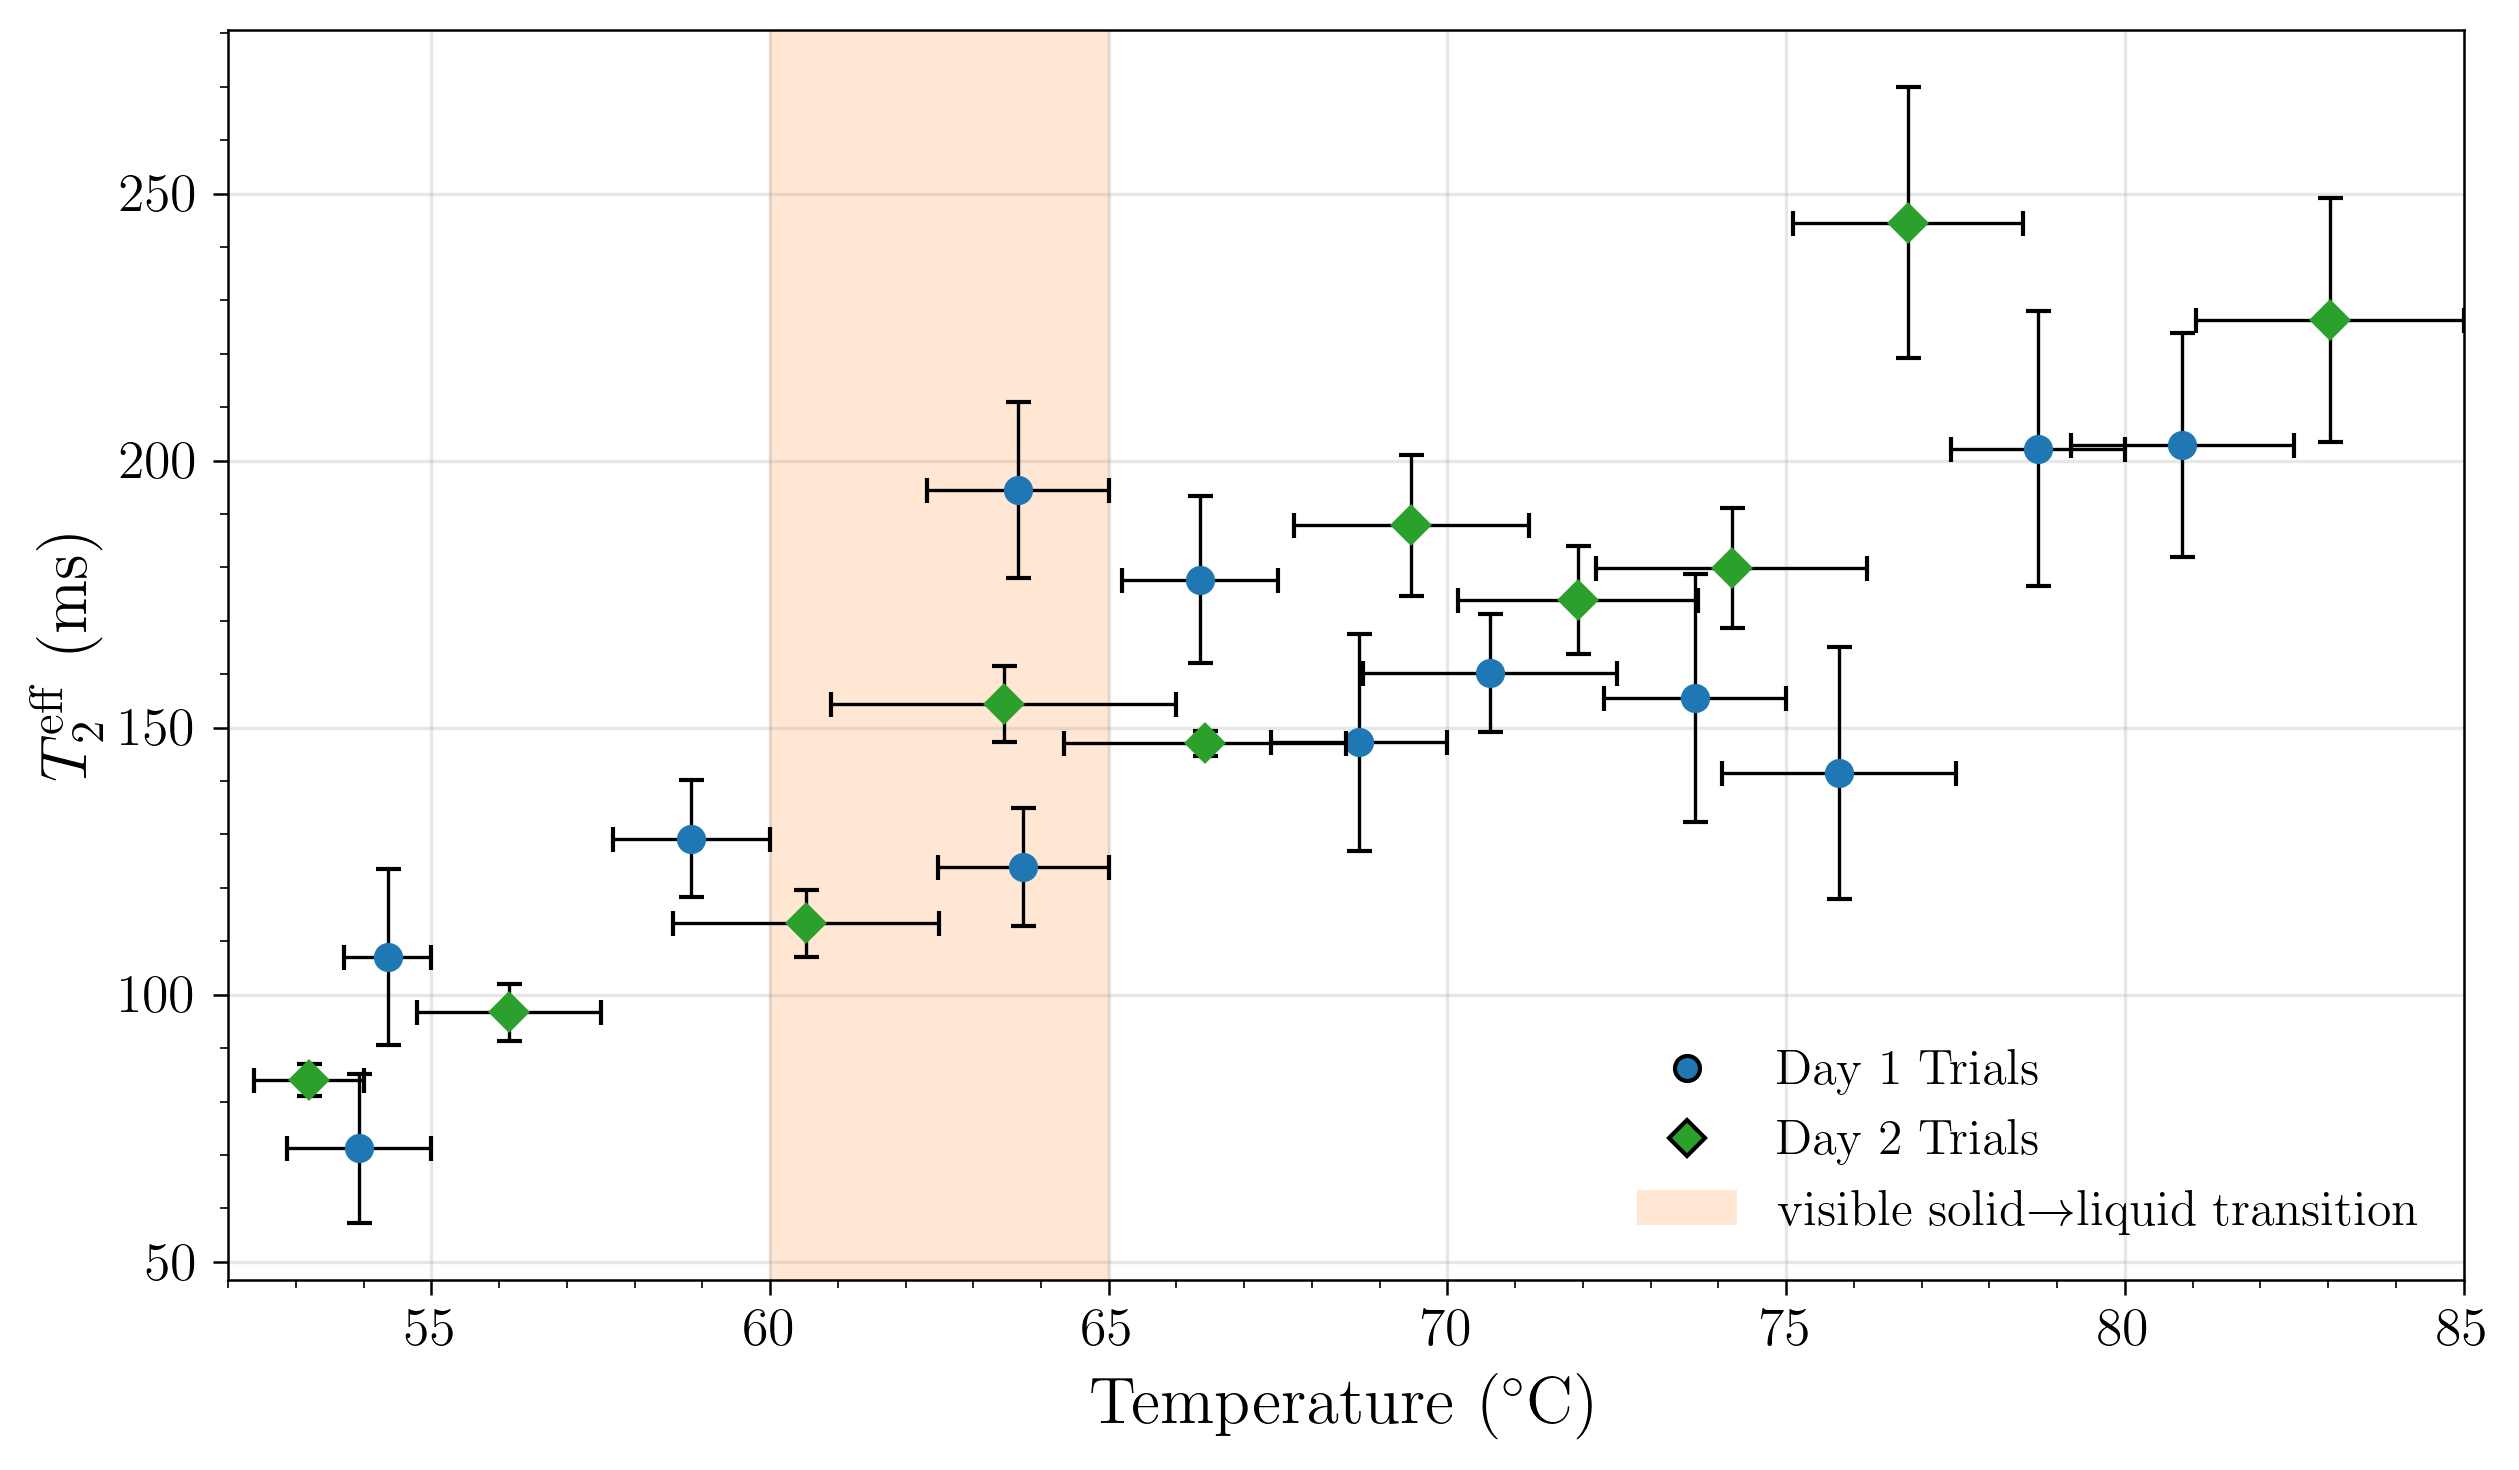

method 3 (local maxima): 22 T2 points


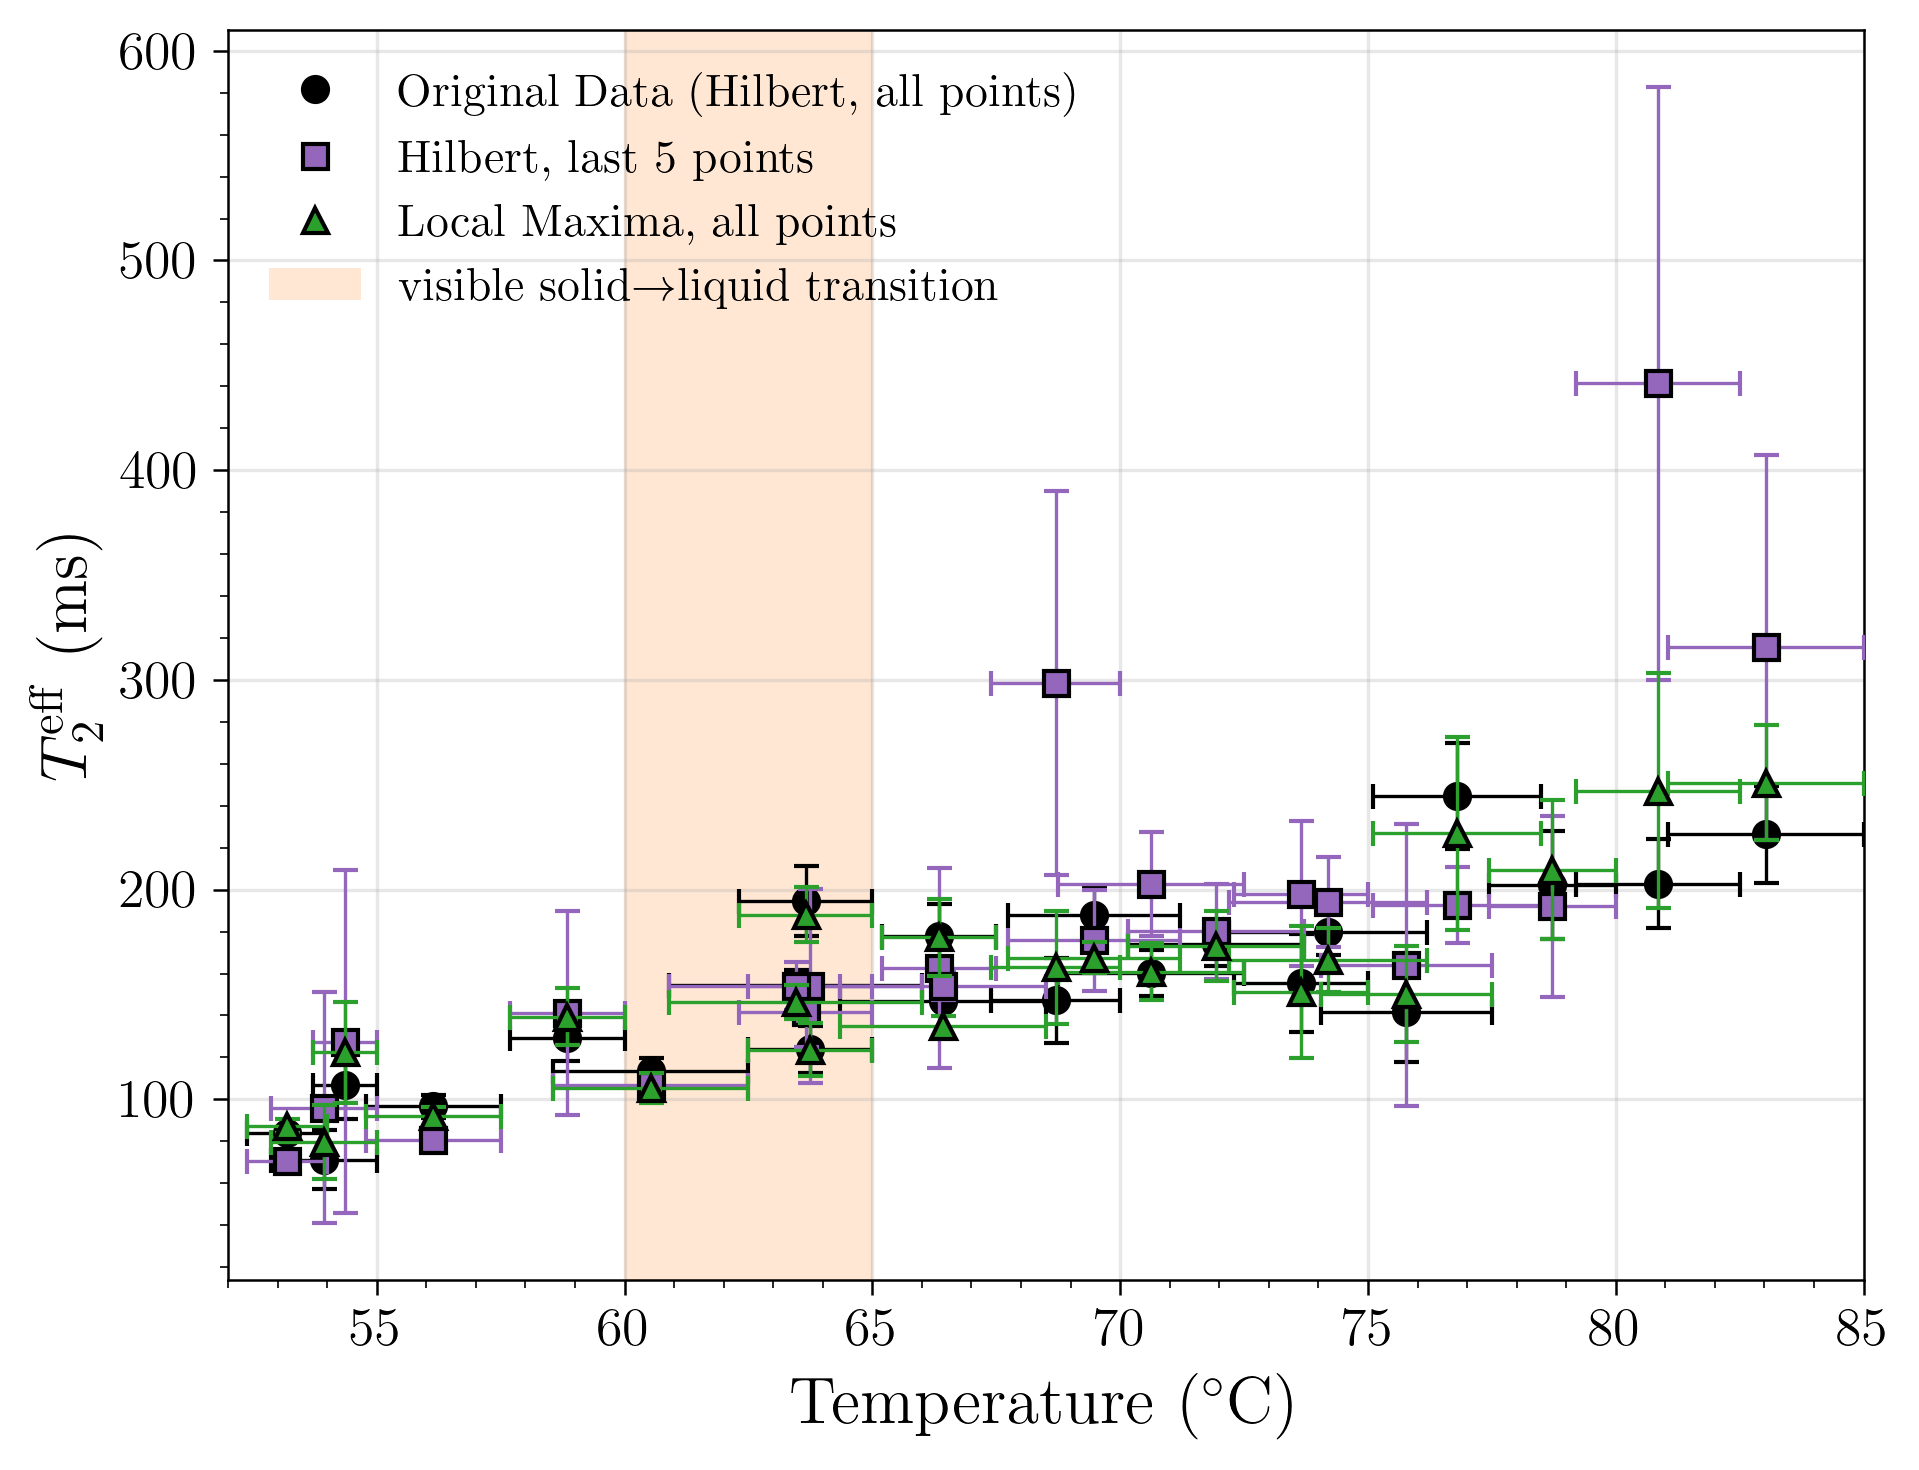

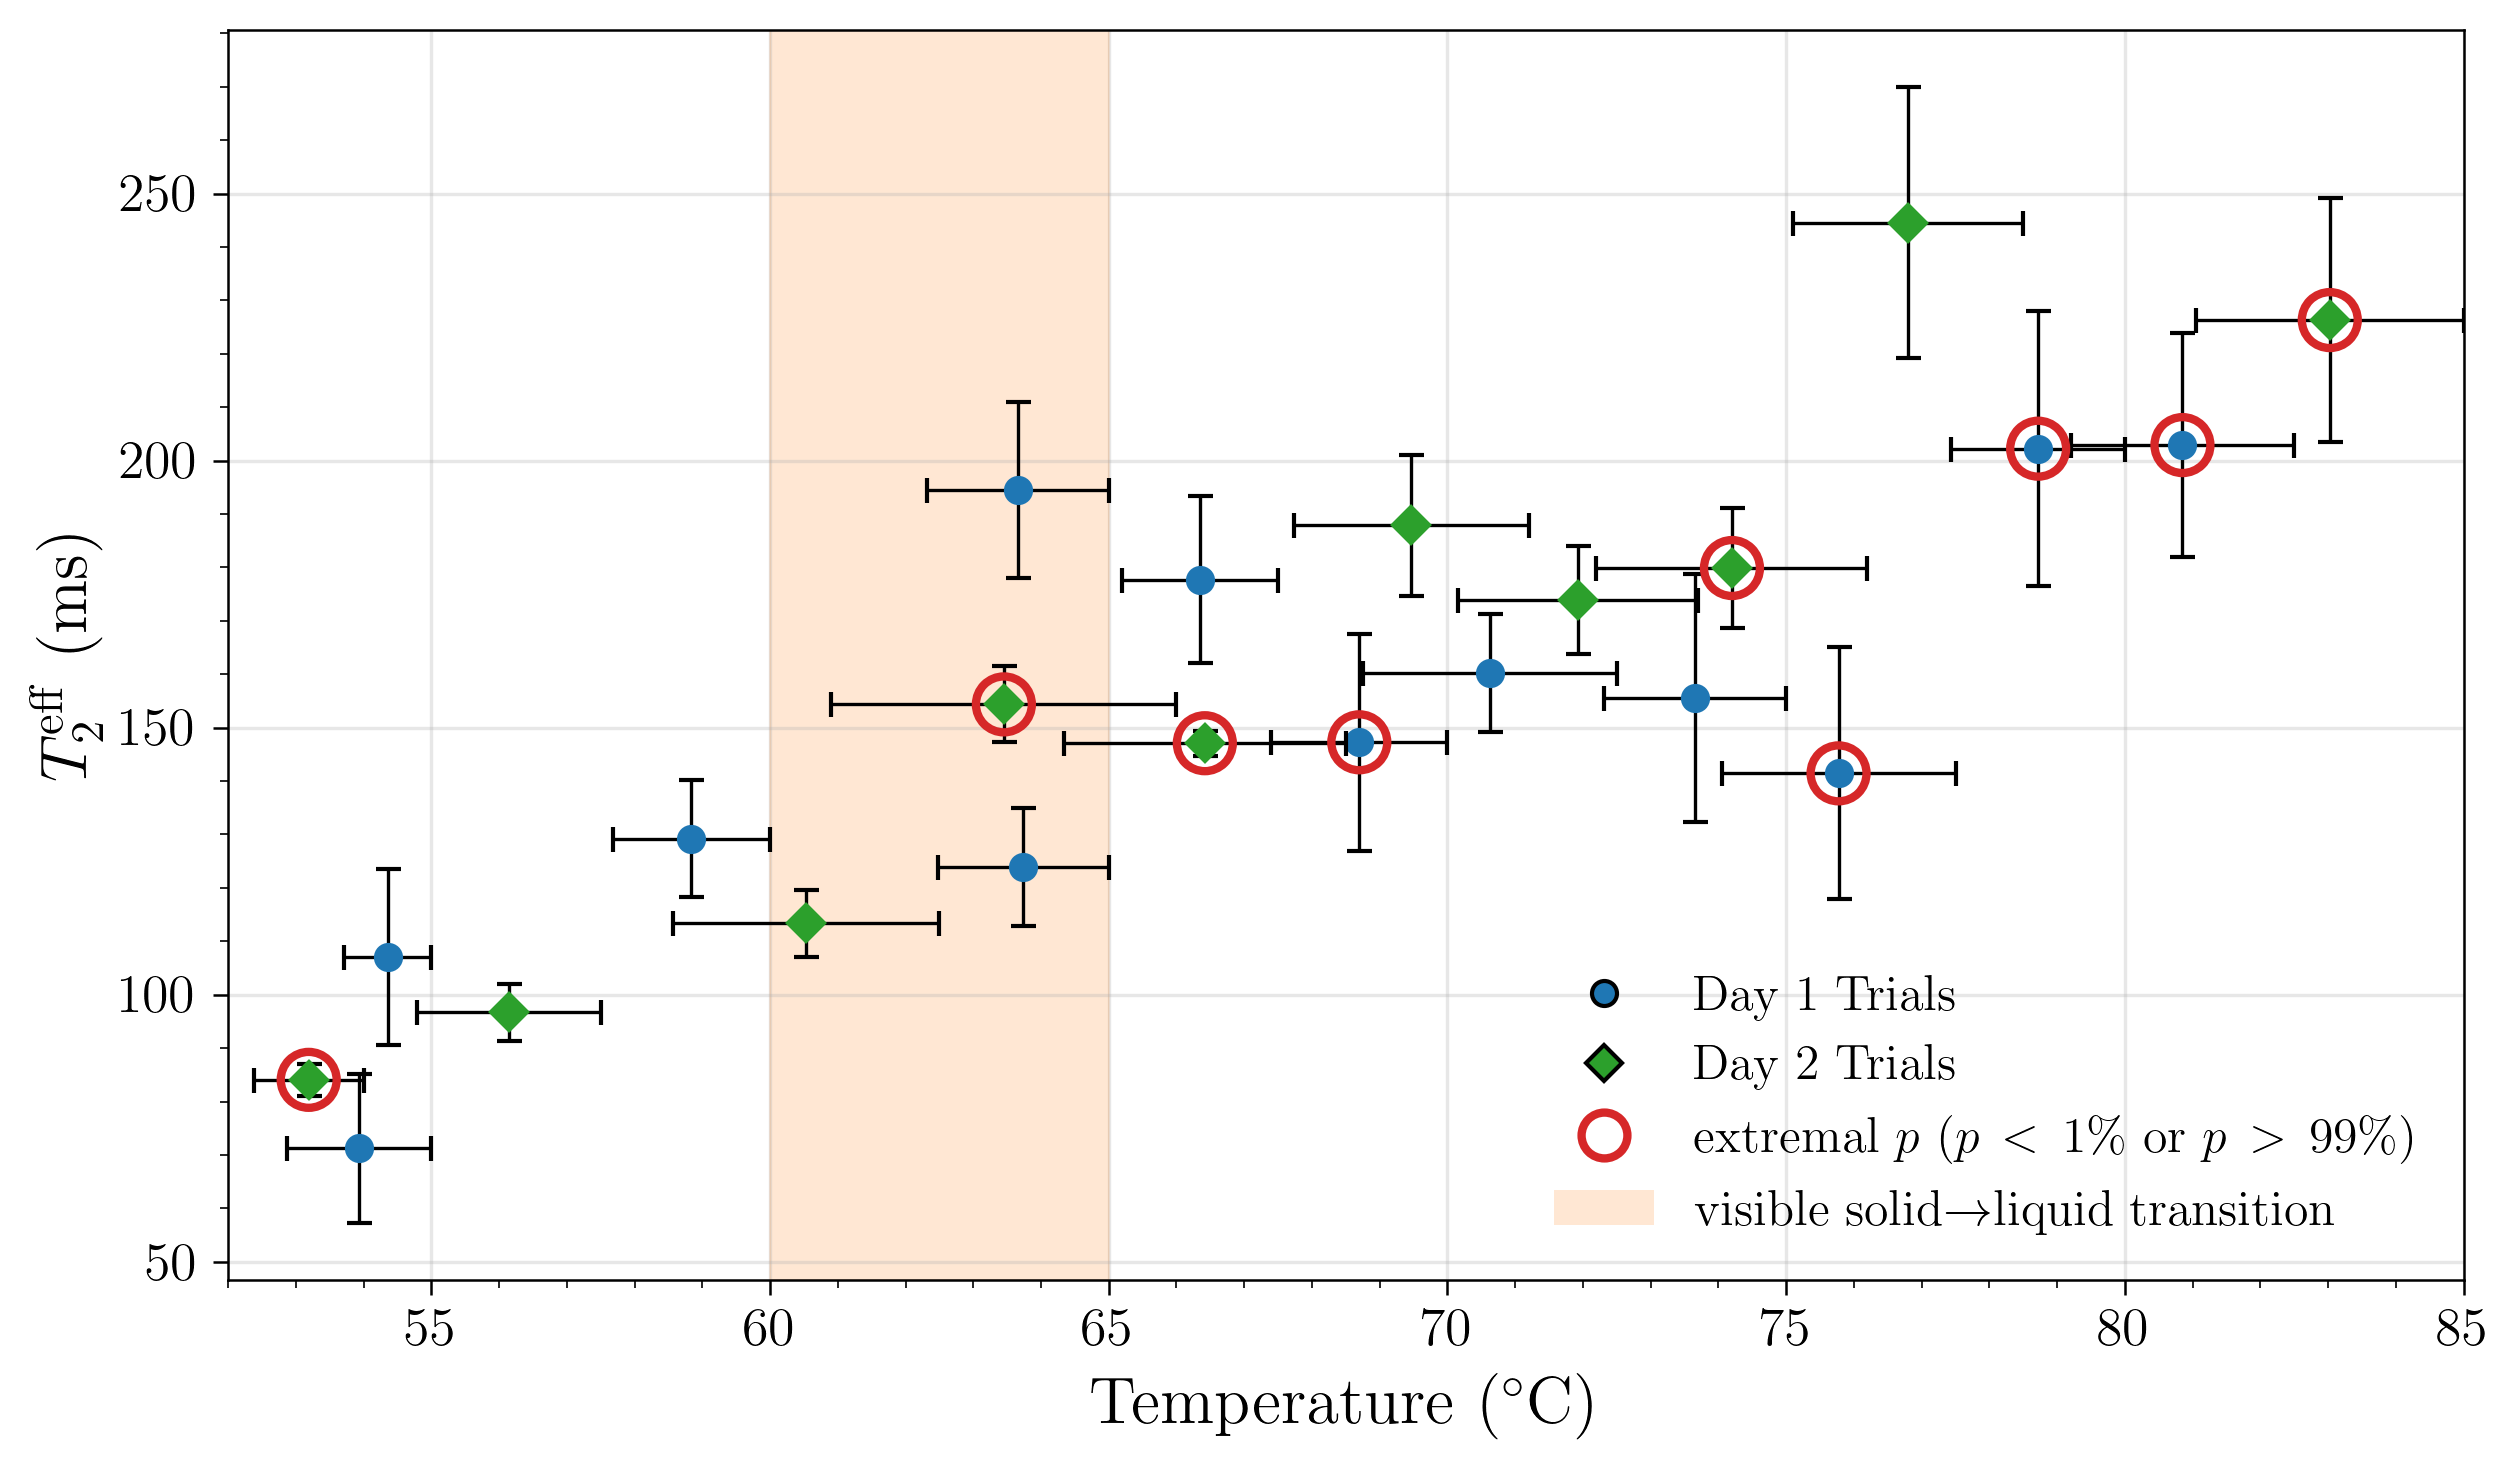

p-value plot: 9 extremal p out of 22 fits

12 10k-sample + 10 100k-sample T2 points (method: Lorentzian, N=16)


In [4]:
import matplotlib.cm as cm

# --- Parse NMR_samples.csv: every "big" beeswax row at T >= T_MIN. Don't
# drop duplicate temperatures — each file becomes its own point.
T_MIN         = 54.0
HIRES_MIN     = 31      # files >= 31 are 100k-sample / 1 us recordings
SHOW_OLD_DATA = False   # toggle archival nmr_old/bwax T2 points on Plot 2
UNIFY_RES     = False    # plot hi-res and lo-res with the same color/marker

samples = pd.read_csv('data/NMR_samples.csv', skiprows=2, header=None,
                     names=['temp_C', 'file_num', 'time_diff_s', 'col1',
                            'sample_size', 'extra'])
samples['sample_size'] = samples['sample_size'].astype(str).str.strip()
samples = samples[samples['sample_size'] == 'big'].copy()
samples['temp_C']      = pd.to_numeric(samples['temp_C'],      errors='coerce')
samples['file_num']    = pd.to_numeric(samples['file_num'],    errors='coerce')
samples['time_diff_s'] = pd.to_numeric(samples['time_diff_s'], errors='coerce')
samples = samples.dropna(subset=['temp_C', 'file_num', 'time_diff_s'])
samples = samples[samples['temp_C'] >= T_MIN]
samples['file_num'] = samples['file_num'].astype(int)
chosen = samples.sort_values(['temp_C', 'file_num'])


# --- Cooling-rate model: averaged |dT/dt|(T) from the 5 calibration curves.
def build_dTdt():
    cal = pd.read_csv('../nmr_old/beeswax_temp_calibration.csv', header=None,
                      skiprows=2,
                      names=['T', 't2', 'u2', 't6', 'u6', 't10', 'u10',
                             't16', 'u16', 't18', 'u18'])
    cal['T'] = pd.to_numeric(cal['T'], errors='coerce')
    cal = cal.dropna(subset=['T']).reset_index(drop=True)
    T_cal = cal['T'].to_numpy(float)

    samples_T, samples_dTdt = [], []
    trials = []
    for col in ['t2', 't6', 't10', 't16', 't18']:
        t_col = pd.to_numeric(cal[col], errors='coerce').to_numpy(float)
        valid = ~np.isnan(t_col)
        if valid.sum() < 3:
            continue
        Tv, tv = T_cal[valid], t_col[valid]
        dTdt = np.gradient(Tv, tv)
        samples_T.append(Tv); samples_dTdt.append(np.abs(dTdt))
        trials.append((Tv, tv))

    T_all   = np.concatenate(samples_T)
    dTdt_all = np.concatenate(samples_dTdt)
    order   = np.argsort(T_all)
    return T_all[order], dTdt_all[order], trials


T_grid, dTdt_grid, trial_data = build_dTdt()


# --- Cooling curves: T(t) for each of the 5 calibration trials,
# rescaled with the thermocouple correction (fixed point 23.8 C,
# recorded 71 C -> actual 85 C) so the y-axis reaches the hottest
# NMR-sample temperature in the dataset.
_T_FP   = 23.8                                # fixed point
_T_SLOPE = (85.0 - 23.8) / (71.0 - 23.8)
def _T_rescale(T_rec_C):
    return _T_SLOPE * (T_rec_C - _T_FP) + _T_FP

fig_cool, ax_cool = plt.subplots(figsize=(8.05, 6))
trial_colors = cm.tab10(np.arange(len(trial_data)))
for i, (Tv, tv) in enumerate(trial_data):
    ax_cool.plot(tv, _T_rescale(Tv), 'o-', ms=5, lw=1.4,
                 color=trial_colors[i], alpha=0.9,
                 label=f'Trial {i+1}')
ax_cool.set_ylim(top=86)
ax_cool.set_xlabel('Time (s)', fontsize=22)
ax_cool.set_ylabel('Temperature ($^\\circ$C)', fontsize=22)
ax_cool.tick_params(labelsize=18)
ax_cool.grid(True, alpha=0.3)
ax_cool.legend(loc='best', fontsize=18)
fig_cool.tight_layout()
fig_cool.savefig(os.path.join(STEP_FIG_DIR, 'cooling_curve.png'),
                 dpi=150, bbox_inches='tight')
plt.show()


def cooling_rate(T_C):
    return np.interp(T_C, T_grid, dTdt_grid)


def extract_echoes(file_num, window_s=0.5e-3):
    """Return (echo_t, amp, amp_unc, t_unc) arrays for one tek file, or
    None. Echo amplitude per echo is delegated to compute_echo_amplitude
    (cell 0) which honors the USE_LORENTZIAN flag. Auto-scales the peak-
    distance to ~500 us so it works for both the 10k-sample (10 us) and
    100k-sample (1 us) recordings."""
    fname = f'data/tek{file_num:04d}.csv'
    d = pd.read_csv(fname, skiprows=20)
    cols = ['TIME', 'CH1', 'CH2']
    d = d[cols].apply(pd.to_numeric, errors='coerce').dropna()
    tt = d['TIME'].to_numpy()
    c1 = d['CH1'].to_numpy(copy=True); c1 -= c1.mean()
    c2 = d['CH2'].to_numpy(copy=True); c2 -= c2.mean()

    sample_dt = float(np.median(np.diff(tt)))
    peak_dist = max(10, int(round(500e-6 / sample_dt)))
    c_file = float(np.median(np.abs(hilbert(c2))))

    pks, _ = find_peaks(np.abs(c1), prominence=0.20 * np.max(np.abs(c1)),
                        distance=peak_dist)
    if len(pks) < 3:
        return None
    pt = tt[pks]
    later = pt[1:]
    if len(later) < 2:
        return None
    Tunit = np.min(np.diff(later))
    span = later[-1] - later[0]
    nint = max(1, int(round(span / Tunit)))
    Tp = span / nint
    n_in = int(np.floor((tt[-1] - later[0]) / Tp)) + 1
    grid = later[0] + np.arange(n_in + 1) * Tp
    echoes = grid[:-1] + Tp / 2

    et, am, ase, te = [], [], [], []
    for x in echoes:
        m = (tt >= x - window_s) & (tt <= x + window_s)
        res = compute_echo_amplitude(tt[m], c2[m], c_fixed=c_file)
        if res is None:
            continue
        et_v, am_v, ae_v, te_v = res
        if not (np.isfinite(am_v) and np.isfinite(ae_v) and ae_v > 0):
            continue
        et.append(et_v); am.append(am_v); ase.append(ae_v); te.append(te_v)
    return np.array(et), np.array(am), np.array(ase), np.array(te)


def find_n_skip(am):
    for i in range(len(am) - 1):
        if am[i + 1] < am[i]:
            return i
    return None


def fit_T2(et, am, ase, te, n_skip):
    if len(et) - n_skip < 3:
        return None
    fit_t = et[n_skip:]; fit_a = am[n_skip:]
    fit_s = ase[n_skip:]; fit_e = te[n_skip:]
    sx = np.where(fit_e > 0, fit_e, 1e-6)

    def model(beta, t):
        return beta[0] * np.exp(-t / beta[1])

    out = odr.ODR(odr.RealData(fit_t, fit_a, sx=sx, sy=fit_s),
                  odr.Model(model),
                  beta0=[fit_a[0], (fit_t[-1] - fit_t[0]) / 2]).run()
    A0, T2v   = out.beta
    A0e, T2e  = out.sd_beta
    chi2v     = out.sum_square
    dofv      = len(fit_t) - 2
    pv        = chi2_dist.sf(chi2v, df=dofv)
    return dict(A0=A0, A0_err=A0e, T2=T2v, T2_err=T2e,
                chi2=chi2v, dof=dofv, p=pv,
                fit_t=fit_t, fit_a=fit_a, fit_s=fit_s, fit_e=fit_e)


# --- Run extraction + fit for each row
results = []
from matplotlib.colors import Normalize
T_min_plot = float(chosen['temp_C'].min())
T_max_plot = float(chosen['temp_C'].max())
T_norm = Normalize(vmin=T_min_plot, vmax=T_max_plot)
T_cmap = cm.viridis
# legacy `cmap` kept as the same per-row colour list (sampled by
# T_corr through the continuous scale) so existing zip(cmap,...) works.
cmap = [T_cmap(T_norm(float(row['temp_C']))) for _, row in chosen.iterrows()]

method_lbl = (f'Lorentzian, N={N_EXTREMA}'
              if USE_LORENTZIAN else f'{2 * N_EXTREMA}-pt extrema')
print(f"Method: {method_lbl}")
print(f"{'T_rec':>5}  {'T_corr':>6}  {'sigT':>5}  {'file':>5}  {'res':>3}  "
      f"{'n_skip':>6}  {'T2 (ms)':>10}  {'sig_T2':>8}  "
      f"{'chi2/nu':>8}  {'p':>7}")
print("-" * 85)

for color, (_, row) in zip(cmap, chosen.iterrows()):
    fnum    = int(row['file_num'])
    T_rec   = float(row['temp_C'])
    dt_wait = float(row['time_diff_s'])
    hires   = fnum >= HIRES_MIN

    delta    = dt_wait * float(cooling_rate(T_rec))
    T_corr   = T_rec - 0.5 * delta
    T_corr_u = 0.5 * delta

    ext = extract_echoes(fnum)
    if ext is None:
        print(f"{T_rec:>5.1f}  {T_corr:>6.2f}  {T_corr_u:>5.2f}  "
              f"{fnum:04d}  {'hi' if hires else 'lo':>3}   extraction failed")
        continue
    et, am, ase, te = ext
    n_skip = find_n_skip(am)
    if n_skip is None:
        print(f"{T_rec:>5.1f}  {T_corr:>6.2f}  {T_corr_u:>5.2f}  "
              f"{fnum:04d}  {'hi' if hires else 'lo':>3}   no decreasing trend")
        continue
    fit = fit_T2(et, am, ase, te, n_skip=n_skip)
    results.append(dict(T_rec=T_rec, T_corr=T_corr, T_corr_u=T_corr_u,
                        file=fnum, color=color, n_skip=n_skip, hires=hires,
                        et=et, am=am, ase=ase, te=te, fit=fit))
    if fit is None:
        print(f"{T_rec:>5.1f}  {T_corr:>6.2f}  {T_corr_u:>5.2f}  "
              f"{fnum:04d}  {'hi' if hires else 'lo':>3}  {n_skip:>6d}   "
              f"too few points after skip")
    else:
        print(f"{T_rec:>5.1f}  {T_corr:>6.2f}  {T_corr_u:>5.2f}  "
              f"{fnum:04d}  {'hi' if hires else 'lo':>3}  {n_skip:>6d}  "
              f"{fit['T2']*1e3:>10.2f}  {fit['T2_err']*1e3:>8.2f}  "
              f"{fit['chi2']/fit['dof']:>8.3f}  {fit['p']:>7.4f}")

# --- Plot 1: all echo amplitudes; omitted points still drawn (black X).
fig, ax = plt.subplots(figsize=(10, 6))
for r in results:
    n = r['n_skip']
    ax.errorbar(r['et'][n:] * 1e3, r['am'][n:] * 1e3,
                xerr=r['te'][n:] * 1e3, yerr=r['ase'][n:] * 1e3,
                fmt='o', ms=4, color=r['color'], ecolor=r['color'],
                elinewidth=0.6, capsize=2, alpha=0.85)
    if n > 0:
        ax.errorbar(r['et'][:n] * 1e3, r['am'][:n] * 1e3,
                    xerr=r['te'][:n] * 1e3, yerr=r['ase'][:n] * 1e3,
                    fmt='o', ms=4, color=r['color'], ecolor=r['color'],
                    elinewidth=0.6, capsize=2, alpha=0.35)
        ax.scatter(r['et'][:n] * 1e3, r['am'][:n] * 1e3,
                   marker='x', s=60, c='black', lw=1.2, zorder=6)
    if r['fit'] is not None:
        f = r['fit']
        tf = np.linspace(f['fit_t'][0], f['fit_t'][-1], 200)
        ax.plot(tf * 1e3, f['A0'] * np.exp(-tf / f['T2']) * 1e3,
                '-', color=r['color'], lw=1.2, alpha=0.9)

ax.set_xlabel('Time (ms)', fontsize=16)
ax.set_ylabel('Voltage (mV)', fontsize=16)
ax.tick_params(labelsize=13)
ax.grid(True, alpha=0.3)

# Colorbar driven by the same temperature norm used for marker colors.
_sm = cm.ScalarMappable(norm=T_norm, cmap=T_cmap)
_sm.set_array([])
_cbar = fig.colorbar(_sm, ax=ax, pad=0.015)
_cbar.set_label('Temperature ($^\\circ$C)', fontsize=16)
_cbar.ax.tick_params(labelsize=13)
plt.tight_layout()
fig.savefig(os.path.join(STEP_FIG_DIR, 'amps_vs_temperature.png'),
            dpi=150, bbox_inches='tight')
plt.show()


# --- Old (nmr_old/bwax_data_new.csv) T2 values, replicated from bwax.ipynb.
def load_old_T2():
    df = pd.read_csv('../nmr_old/bwax_data_new.csv', header=0)
    tau_row = df.iloc[0]
    temp_df = df.iloc[2:14]
    calib_px_row = df.iloc[14]
    calib_mV_row = df.iloc[15]
    val_slice = slice(1, None, 2); unc_slice = slice(2, None, 2)

    temperatures = temp_df.iloc[:, 0].values.astype(float)
    raw_px  = temp_df.iloc[:, val_slice].values.astype(float)
    raw_unc = temp_df.iloc[:, unc_slice].values.astype(float)
    taus    = tau_row.iloc[val_slice].values.astype(float)
    calib_px = calib_px_row.iloc[val_slice].values.astype(float)
    calib_uc = calib_px_row.iloc[unc_slice].values.astype(float)
    calib_mV = calib_mV_row.iloc[val_slice].values.astype(float)

    slope = (80 - 23.8) / (70 - 23.8)
    T_act = slope * (temperatures - 23.8) + 23.8
    T_unc = (5 / (70 - 23.8)) * (temperatures - 23.8)

    scale = calib_mV / calib_px
    amp_mV = raw_px * scale[None, :]
    amp_unc_mV = amp_mV * np.sqrt((raw_unc / raw_px) ** 2 +
                                  (calib_uc / calib_px) ** 2)

    fit_mask = np.isin(taus, [10, 16, 18])
    taus_fit = taus[fit_mask]

    def exp_decay(tau, A0, T2):
        return A0 * np.exp(-2 * tau / T2)

    T2_arr = np.full(len(T_act), np.nan)
    T2_err = np.full(len(T_act), np.nan)
    for i in range(len(T_act)):
        y = amp_mV[i, fit_mask]; yerr = amp_unc_mV[i, fit_mask]
        try:
            popt, pcov = curve_fit(exp_decay, taus_fit, y,
                                   p0=[y[0] * np.exp(taus_fit[0] / 15), 15.0],
                                   sigma=yerr, absolute_sigma=True)
            T2_arr[i] = popt[1]; T2_err[i] = np.sqrt(pcov[1, 1])
        except Exception:
            pass
    return T_act, T_unc, T2_arr, T2_err


# --- Plot 2: T2 vs temperature; uncorrected (faded) + cooling-corrected.
# Rejects degenerate ODR fits: σ_T2 = 0 (singular covariance), T2 > 10 s
# (unphysical), or σ_T2/T2 > 5 (badly under-constrained).
fitted = [r for r in results
          if r['fit'] is not None
          and np.isfinite(r['fit']['T2'])
          and np.isfinite(r['fit']['T2_err'])
          and r['fit']['T2'] > 0
          and r['fit']['T2'] < 10.0
          and r['fit']['T2_err'] > 0
          and r['fit']['T2_err'] < 5 * r['fit']['T2']]

lo = [r for r in fitted if not r['hires']]
hi = [r for r in fitted if     r['hires']]

def arrs(group):
    Tr  = np.array([r['T_rec']    for r in group])
    Tc  = np.array([r['T_corr']   for r in group])
    Tcu = np.array([r['T_corr_u'] for r in group])
    T2  = np.array([r['fit']['T2']     for r in group]) * 1e3
    T2e = np.array([r['fit']['T2_err'] for r in group]) * 1e3
    return Tr, Tc, Tcu, T2, T2e

T_lo_rec, T_lo_c, T_lo_cu, T2_lo, T2_lo_err = arrs(lo)
T_hi_rec, T_hi_c, T_hi_cu, T2_hi, T2_hi_err = arrs(hi)

fig, ax = plt.subplots(figsize=(8.5, 5))

# Visual phase transition (solid <-> liquid) observed in the
# 60-65 C range during the experiment.
ax.axvspan(60, 65, color='tab:orange', alpha=0.18, zorder=0)

if SHOW_OLD_DATA:
    T_old, T_old_unc, T2_old, T2_old_err = load_old_T2()
    ax.errorbar(T_old, T2_old, xerr=T_old_unc, yerr=T2_old_err,
                fmt='s', ms=5, color='lightcoral', ecolor='lightcoral',
                mec='lightcoral', mfc='lightcoral',
                elinewidth=0.6, capsize=2, alpha=0.4, zorder=1,
                label='nmr\\_old/bwax (3-pt $\\tau$=10,16,18 ms)')
    n_old = int(np.sum(np.isfinite(T2_old)))
else:
    n_old = 0

if UNIFY_RES:
    T_rec_all  = np.concatenate([T_lo_rec,  T_hi_rec])
    T_corr_all = np.concatenate([T_lo_c,    T_hi_c])
    Tu_all     = np.concatenate([T_lo_cu,   T_hi_cu])
    T2_all     = np.concatenate([T2_lo,     T2_hi])
    T2e_all    = np.concatenate([T2_lo_err, T2_hi_err])

    if len(T_corr_all):
        ax.errorbar(T_corr_all, T2_all, xerr=Tu_all, yerr=T2e_all,
                    fmt='o', ms=6, color='tab:blue', ecolor='black',
                    elinewidth=0.8, capsize=3, zorder=4,
                    label='cooling-corrected $T$')
else:
    if len(T_lo_c):
        ax.errorbar(T_lo_c, T2_lo, xerr=T_lo_cu, yerr=T2_lo_err,
                    fmt='o', ms=6, color='tab:blue', ecolor='black',
                    elinewidth=0.8, capsize=3, zorder=4,
                    )
    if len(T_hi_c):
        ax.errorbar(T_hi_c, T2_hi, xerr=T_hi_cu, yerr=T2_hi_err,
                    fmt='D', ms=6, color='tab:green', ecolor='black',
                    elinewidth=0.8, capsize=3, zorder=5,
                    )

all_T_x = (T_corr_all if UNIFY_RES
           else np.concatenate([T_lo_c, T_hi_c]))
T_low_axis = float(np.floor(np.min(all_T_x) - 1)) if len(all_T_x) else T_MIN
ax.set_xlim(T_low_axis, 85)

ax.set_xlabel('Temperature ($^\\circ$C)', fontsize=16)
ax.set_ylabel('$T_2^{\mathrm{eff}}$ (ms)', fontsize=16)
ax.tick_params(labelsize=13)
ax.grid(True, alpha=0.3)
from matplotlib.patches import Patch as _Patch
from matplotlib.lines import Line2D as _Line2D
_p2_handles = [
    _Line2D([], [], marker='o', ms=6, linestyle='', color='tab:blue',
            mec='black', label='Day 1 Trials'),
    _Line2D([], [], marker='D', ms=6, linestyle='', color='tab:green',
            mec='black', label='Day 2 Trials'),
    _Patch(facecolor='tab:orange', alpha=0.18,
           label='visible solid$\\rightarrow$liquid transition'),
]
ax.legend(handles=_p2_handles, loc='best', fontsize=12)
plt.tight_layout()
plt.gcf().savefig(os.path.join(STEP_FIG_DIR, 'T2_vs_temperature.png'),
                  dpi=150, bbox_inches='tight')
plt.show()


# --- Plot 2b: model-uncertainty view. Two alternate methods overlaid
# on the original method:
#   (1) original  — bandpassed |hilbert(...)| envelope, fit T2 on all
#                   post-skip echoes  (BLACK)
#   (2) last-N    — same envelope as (1) but T2 fit on only the last
#                   N_LAST_ALT echoes  (PURPLE)
#   (3) localmax  — per-cycle local maxima of |CH2| as the envelope
#                   (no Hilbert, no bandpass); T2 fit on all post-
#                   skip echoes  (TEAL)
N_LAST_ALT = 5

def _fit_lorentzian_envelope(t_win, ch2_win):
    """Mirror of fit_lorentzian_to_window but uses the per-cycle
    local maxima of |CH2| as the envelope (no Hilbert / FFT bandpass).
    Returns the same dict shape so downstream code is unchanged."""
    if len(ch2_win) < 8:
        return None
    sample_dt = float(np.median(np.diff(t_win)))
    if not np.isfinite(sample_dt) or sample_dt <= 0:
        return None
    abs_w = np.abs(ch2_win)
    pk_idx, _ = find_peaks(abs_w)
    if len(pk_idx) < 4:
        return None
    tp = t_win[pk_idx]
    yp = abs_w[pk_idx]
    A0 = float(yp.max() - yp.min())
    if A0 <= 0:
        return None
    t0_0 = float(tp[np.argmax(yp)])
    span_t = float(tp[-1] - tp[0])
    if span_t <= 0:
        return None
    gamma_0 = max(span_t / 4.0, 5 * sample_dt)
    bounds_lo = [0.0,                    tp[0],  2.0 * sample_dt]
    bounds_hi = [10.0 * float(yp.max()), tp[-1], span_t]
    p0 = [min(max(float(yp.max()), bounds_lo[0] + 1e-12), bounds_hi[0] - 1e-12),
          min(max(t0_0, bounds_lo[1]), bounds_hi[1]),
          min(max(gamma_0, bounds_lo[2]), bounds_hi[2])]
    try:
        popt, pcov = curve_fit(lorentzian, tp, yp, p0=p0,
                               bounds=(bounds_lo, bounds_hi), maxfev=5000)
    except Exception:
        return None
    if not np.all(np.isfinite(pcov)):
        return None
    A, t0, gamma = popt
    diag = np.diag(pcov); diag = np.where(diag < 0, 0.0, diag)
    A_err = float(np.sqrt(diag[0]))
    t0_err = float(np.sqrt(diag[1]))
    if not (np.isfinite(A) and np.isfinite(A_err)):
        return None
    A_err = max(A_err, 1e-6 * abs(A) if A != 0 else 1e-9)
    data_peak = float(np.abs(ch2_win).max())
    gap = float(A) - data_peak
    delta = abs(gap)
    A_corr = float(A) - 0.5 * gap
    A_total_err = float(np.sqrt(A_err ** 2 + (0.5 * delta) ** 2))
    return dict(amp=A_corr, amp_err=A_total_err,
                t0=float(t0), t0_err=t0_err)

def _extract_echoes_envelope(file_num, window_s=0.5e-3):
    fname = f'data/tek{file_num:04d}.csv'
    d = pd.read_csv(fname, skiprows=20)
    d = d[['TIME', 'CH1', 'CH2']].apply(pd.to_numeric, errors='coerce').dropna()
    tt = d['TIME'].to_numpy()
    c1 = d['CH1'].to_numpy(copy=True); c1 -= c1.mean()
    c2 = d['CH2'].to_numpy(copy=True); c2 -= c2.mean()
    sample_dt_ = float(np.median(np.diff(tt)))
    peak_dist = max(10, int(round(500e-6 / sample_dt_)))
    pks, _ = find_peaks(np.abs(c1), prominence=0.20 * np.max(np.abs(c1)),
                        distance=peak_dist)
    if len(pks) < 3:
        return None
    pt = tt[pks]; later = pt[1:]
    if len(later) < 2:
        return None
    Tunit = np.min(np.diff(later))
    span_ = later[-1] - later[0]
    nint = max(1, int(round(span_ / Tunit)))
    Tp = span_ / nint
    n_in = int(np.floor((tt[-1] - later[0]) / Tp)) + 1
    grid_ = later[0] + np.arange(n_in + 1) * Tp
    echoes = grid_[:-1] + Tp / 2
    et_, am_, ase_, te_ = [], [], [], []
    for x in echoes:
        m = (tt >= x - window_s) & (tt <= x + window_s)
        rr = _fit_lorentzian_envelope(tt[m], c2[m])
        if rr is None or not np.isfinite(rr['amp']) or rr['amp_err'] <= 0:
            continue
        et_.append(rr['t0']); am_.append(rr['amp'])
        ase_.append(rr['amp_err']); te_.append(rr['t0_err'])
    return np.array(et_), np.array(am_), np.array(ase_), np.array(te_)

# --- Method 2: last-N-only T2 fit (same envelope as method 1).
alt_T_corr, alt_T_corr_u, alt_T2, alt_T2_err = [], [], [], []
for r in results:
    et, am, ase_, te_ = r['et'], r['am'], r['ase'], r['te']
    if len(et) < N_LAST_ALT + 1:
        continue
    n_skip_alt = len(et) - N_LAST_ALT
    fit_alt = fit_T2(et, am, ase_, te_, n_skip=n_skip_alt)
    if fit_alt is None or not np.isfinite(fit_alt['T2']) or fit_alt['T2'] <= 0:
        continue
    alt_T_corr.append(r['T_corr'])
    alt_T_corr_u.append(r['T_corr_u'])
    alt_T2.append(fit_alt['T2'] * 1e3)
    alt_T2_err.append(fit_alt['T2_err'] * 1e3)
alt_T_corr   = np.array(alt_T_corr)
alt_T_corr_u = np.array(alt_T_corr_u)
alt_T2       = np.array(alt_T2)
alt_T2_err   = np.array(alt_T2_err)

# --- Method 3: per-cycle local-maxima envelope.
env_T_corr, env_T_corr_u, env_T2, env_T2_err = [], [], [], []
for r in results:
    ext = _extract_echoes_envelope(r['file'])
    if ext is None:
        continue
    et_e, am_e, ase_e, te_e = ext
    if len(et_e) < 4:
        continue
    n_skip_e = find_n_skip(am_e)
    if n_skip_e is None:
        continue
    fit_e = fit_T2(et_e, am_e, ase_e, te_e, n_skip=n_skip_e)
    if fit_e is None or not np.isfinite(fit_e['T2']) or fit_e['T2'] <= 0:
        continue
    env_T_corr.append(r['T_corr'])
    env_T_corr_u.append(r['T_corr_u'])
    env_T2.append(fit_e['T2'] * 1e3)
    env_T2_err.append(fit_e['T2_err'] * 1e3)
env_T_corr   = np.array(env_T_corr)
env_T_corr_u = np.array(env_T_corr_u)
env_T2       = np.array(env_T2)
env_T2_err   = np.array(env_T2_err)
print(f'method 3 (local maxima): {len(env_T_corr)} T2 points')

fig2b, ax2b = plt.subplots(figsize=(6.5, 5))
ax2b.axvspan(60, 65, color='tab:orange', alpha=0.18, zorder=0)

# Original-method points (all-post-skip fit) in BLACK.
T_all_c   = np.concatenate([T_lo_c, T_hi_c])
T_all_cu  = np.concatenate([T_lo_cu, T_hi_cu])
T2_all2   = np.concatenate([T2_lo, T2_hi])
T2_all_err = np.concatenate([T2_lo_err, T2_hi_err])
if len(T_all_c):
    ax2b.errorbar(T_all_c, T2_all2, xerr=T_all_cu, yerr=T2_all_err,
                  fmt='o', ms=6, color='black', ecolor='black',
                  elinewidth=0.8, capsize=3, zorder=4,
                  label='Original Data (Hilbert, all points)')
if len(alt_T_corr):
    ax2b.errorbar(alt_T_corr, alt_T2, xerr=alt_T_corr_u, yerr=alt_T2_err,
                  fmt='s', ms=6, color='tab:purple',
                  ecolor='tab:purple', mec='black',
                  elinewidth=0.8, capsize=3, zorder=5,
                  label=f'Hilbert, last {N_LAST_ALT} points')
if len(env_T_corr):
    ax2b.errorbar(env_T_corr, env_T2, xerr=env_T_corr_u, yerr=env_T2_err,
                  fmt='^', ms=6, color='tab:green',
                  ecolor='tab:green', mec='black',
                  elinewidth=0.8, capsize=3, zorder=6,
                  label='Local Maxima, all points')

ax2b.set_xlim(T_low_axis, 85)
ax2b.set_xlabel('Temperature ($^\\circ$C)', fontsize=16)
ax2b.set_ylabel('$T_2^{\mathrm{eff}}$ (ms)', fontsize=16)
ax2b.tick_params(labelsize=13)
ax2b.grid(True, alpha=0.3)
_p2b_handles = [
    _Line2D([], [], marker='o', ms=6, linestyle='', color='black',
            label='Original Data (Hilbert, all points)'),
    _Line2D([], [], marker='s', ms=6, linestyle='', color='tab:purple',
            mec='black', label=f'Hilbert, last {N_LAST_ALT} points'),
    _Line2D([], [], marker='^', ms=6, linestyle='', color='tab:green',
            mec='black', label='Local Maxima, all points'),
    _Patch(facecolor='tab:orange', alpha=0.18,
           label='visible solid$\\rightarrow$liquid transition'),
]
ax2b.legend(handles=_p2b_handles, loc='best', fontsize=11)
fig2b.tight_layout()
fig2b.savefig(os.path.join(STEP_FIG_DIR, 'T2_vs_temperature_model_unc.png'),
              dpi=150, bbox_inches='tight')
plt.show()


# --- Plot 2c: same data as Plot 2 but colored by ODR fit p-value.
# Green = 1% <= p <= 99% (acceptable goodness-of-fit). Red = the
# fit is rejected at the 1% level on either tail (too tight or too
# loose to be consistent with the chi^2 distribution).
fig2c, ax2c = plt.subplots(figsize=(8.5, 5))
ax2c.axvspan(60, 65, color='tab:orange', alpha=0.18, zorder=0)

# Day 1 / Day 2 base layers (same as Plot 2).
if len(T_lo_c):
    ax2c.errorbar(T_lo_c, T2_lo, xerr=T_lo_cu, yerr=T2_lo_err,
                  fmt='o', ms=6, color='tab:blue', ecolor='black',
                  elinewidth=0.8, capsize=3, zorder=4)
if len(T_hi_c):
    ax2c.errorbar(T_hi_c, T2_hi, xerr=T_hi_cu, yerr=T2_hi_err,
                  fmt='D', ms=6, color='tab:green', ecolor='black',
                  elinewidth=0.8, capsize=3, zorder=5)

# Red ring overlay: points whose ODR fit has p<1% or p>99%.
ext_T, ext_T2 = [], []
for r in results:
    if r['fit'] is None:
        continue
    p = r['fit']['p']
    if not np.isfinite(p):
        continue
    if p < 0.01 or p > 0.99:
        ext_T.append(r['T_corr'])
        ext_T2.append(r['fit']['T2'] * 1e3)
if ext_T:
    ax2c.scatter(ext_T, ext_T2, s=180, facecolors='none',
                 edgecolors='tab:red', linewidths=2.0, zorder=10)

_p2c_handles = [
    _Line2D([], [], marker='o', ms=6, linestyle='', color='tab:blue',
            mec='black', label='Day 1 Trials'),
    _Line2D([], [], marker='D', ms=6, linestyle='', color='tab:green',
            mec='black', label='Day 2 Trials'),
    _Line2D([], [], marker='o', ms=11, linestyle='',
            mfc='none', mec='tab:red', mew=2.0,
            label=r'extremal $p$ ($p\,<\,1\%$ or $p\,>\,99\%$)'),
    _Patch(facecolor='tab:orange', alpha=0.18,
           label='visible solid$\\rightarrow$liquid transition'),
]

ax2c.set_xlim(T_low_axis, 85)
ax2c.set_xlabel('Temperature ($^\\circ$C)', fontsize=16)
ax2c.set_ylabel(r'$T_2^{\mathrm{eff}}$ (ms)', fontsize=16)
ax2c.tick_params(labelsize=13)
ax2c.grid(True, alpha=0.3)
ax2c.legend(handles=_p2c_handles, loc='best', fontsize=12)
fig2c.tight_layout()
fig2c.savefig(os.path.join(STEP_FIG_DIR, 'T2_vs_temperature_pvalue.png'),
              dpi=150, bbox_inches='tight')
plt.show()
print(f'p-value plot: {len(ext_T)} extremal p out of {len(results)} fits')

print(f"\n{len(lo)} 10k-sample + {len(hi)} 100k-sample T2 points "
      f"(method: {method_lbl})"
      + (f" + {n_old} old-data T2 points" if SHOW_OLD_DATA else ""))

In [5]:
import os
import shutil
import matplotlib

# Per-temperature diagnostic dump: regenerate the example-cell figures for
# every file in `results` and write them to disk. Saved as PNGs only — not
# shown inline. Toggle this off when the figures are already up to date so
# the cell finishes quickly.
REGEN_FIGURES = False
OUT_DIR = 'figures'

if REGEN_FIGURES:
    shutil.rmtree(OUT_DIR, ignore_errors=True)
    os.makedirs(OUT_DIR, exist_ok=True)
    _orig_backend = matplotlib.get_backend()
    plt.switch_backend('Agg')


def _save_extrema_plot(r, path):
    fname = f'data/tek{r["file"]:04d}.csv'
    d = pd.read_csv(fname, skiprows=20)
    d = d[['TIME', 'CH1', 'CH2']].apply(pd.to_numeric, errors='coerce').dropna()
    tt = d['TIME'].to_numpy()
    c1 = d['CH1'].to_numpy(copy=True); c1 -= c1.mean()
    c2 = d['CH2'].to_numpy(copy=True); c2 -= c2.mean()

    sample_dt = float(np.median(np.diff(tt)))
    peak_dist = max(10, int(round(500e-6 / sample_dt)))
    c_file = float(np.median(np.abs(hilbert(c2))))
    pks, _ = find_peaks(np.abs(c1), prominence=0.20 * np.max(np.abs(c1)),
                        distance=peak_dist)
    pt = tt[pks]
    later = pt[1:]
    Tunit = np.min(np.diff(later))
    span = later[-1] - later[0]
    nint = max(1, int(round(span / Tunit)))
    Tp = span / nint
    n_in = int(np.floor((tt[-1] - later[0]) / Tp)) + 1
    grid_180 = later[0] + np.arange(n_in + 1) * Tp
    echoes = grid_180[:-1] + Tp / 2

    window_s = 0.5e-3
    c2_max = float(np.max(np.abs(c2)))
    c1_s = c1 * (c2_max / np.max(np.abs(c1)))

    fig, ax = plt.subplots(figsize=(10, 5))
    _yspan_mV = 1e3 * float(c2.max() - c2.min())
    _yheight  = 1.2 * _yspan_mV
    _ycenter  = 0.5 * 1e3 * float(np.abs(c2).max())
    ax.set_xlim(0.0, tt.max() * 1e3)
    ax.set_ylim(_ycenter - _yheight / 2, _ycenter + _yheight / 2)

    if USE_LORENTZIAN:
        # Step 2b-style: faded |CH2|, Lorentzian fit curves spanning midpoint-
        # to-midpoint between echoes, black markers at each fit peak.
        ax.plot(tt * 1e3, np.abs(c2) * 1e3, color='tab:orange', lw=0.5,
                alpha=0.20, label='$|$CH2$|$ (AC-coupled)')
        lorentz_results = {}
        for i, te in enumerate(echoes):
            m = (tt >= te - window_s) & (tt <= te + window_s)
            if m.sum() < 8:
                continue
            r_ = fit_lorentzian_to_window(tt[m], c2[m], c_fixed=c_file)
            if r_ is None:
                continue
            lorentz_results[i] = r_
        fit_curve_label_done = False
        for i, te in enumerate(echoes):
            if i not in lorentz_results:
                continue
            r_ = lorentz_results[i]
            prev_te = (echoes[i - 1] if i > 0
                       else 2 * te - echoes[i + 1])
            next_te = (echoes[i + 1] if i + 1 < len(echoes)
                       else 2 * te - echoes[i - 1])
            t_left  = max(tt.min(), 0.5 * (prev_te + te))
            t_right = min(tt.max(), 0.5 * (te + next_te))
            t_curve = np.linspace(t_left, t_right, 400)
            ax.plot(t_curve * 1e3,
                    lorentzian(t_curve, r_['amp_raw'], r_['t0'],
                               r_['gamma']) * 1e3,
                    color='tab:red', lw=2.0, zorder=6,
                    label='Lorentzian fit'
                    if not fit_curve_label_done else None)
            fit_curve_label_done = True
        peak_t   = np.array([r_['t0']      for r_ in lorentz_results.values()])
        peak_y   = np.array([r_['amp']     for r_ in lorentz_results.values()])
        peak_xe  = np.array([r_['t0_err']  for r_ in lorentz_results.values()])
        peak_ye  = np.array([r_['amp_err'] for r_ in lorentz_results.values()])
        if len(peak_t):
            ax.errorbar(peak_t * 1e3, peak_y * 1e3,
                        xerr=peak_xe * 1e3, yerr=peak_ye * 1e3,
                        fmt='o', ms=8, color='black', ecolor='black',
                        elinewidth=1.0, capsize=3, zorder=7,
                        label='Spin echo amplitude peaks')
    else:
        ax.plot(tt * 1e3, c2 * 1e3, color='tab:orange', lw=0.8, label='CH2')
        for i, te in enumerate(echoes):
            ax.axvspan((te - window_s) * 1e3, (te + window_s) * 1e3,
                       color='tab:orange', alpha=0.10,
                       label=f'echo $\\pm$ {window_s*1e3:.0f} ms' if i == 0 else None)
        pos_t, pos_y, neg_t, neg_y = [], [], [], []
        for x in echoes:
            m = (tt >= x - window_s) & (tt <= x + window_s)
            yi = c2[m]; ti = tt[m]
            if len(yi) < 2 * N_EXTREMA:
                continue
            order = np.argsort(yi)
            pos_t.extend(ti[order[-N_EXTREMA:]]); pos_y.extend(yi[order[-N_EXTREMA:]])
            neg_t.extend(ti[order[:N_EXTREMA]]);  neg_y.extend(yi[order[:N_EXTREMA]])
        if pos_t:
            ax.scatter(np.array(pos_t) * 1e3, np.array(pos_y) * 1e3, s=70, c='crimson',
                       zorder=5, edgecolor='black', lw=0.4,
                       label=f'top {N_EXTREMA} max')
        if neg_t:
            ax.scatter(np.array(neg_t) * 1e3, np.array(neg_y) * 1e3, s=70, c='royalblue',
                       zorder=5, edgecolor='black', lw=0.4,
                       label=f'top {N_EXTREMA} min')

    method_short = ('Lorentzian (Hilbert env.)' if USE_LORENTZIAN
                    else f'{2 * N_EXTREMA}-point extrema')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Voltage (mV)')
    ax.set_title(f"tek{r['file']:04d}, T = {r['T_rec']:.1f} $^\\circ$C: "
                 f"echoes + {method_short}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=10)
    fig.tight_layout()
    fig.savefig(path, dpi=120, bbox_inches='tight')
    plt.close(fig)


def _save_t2fit_plot(r, path):
    if r['fit'] is None:
        return
    n = r['n_skip']
    f = r['fit']

    method_short = ('Lorentzian (Hilbert env.)' if USE_LORENTZIAN
                    else f'{2 * N_EXTREMA}-pt extrema')

    fig, ax = plt.subplots(figsize=(9, 5))
    if n > 0:
        ax.errorbar(r['et'][:n] * 1e3, r['am'][:n] * 1e3,
                    xerr=r['te'][:n] * 1e3, yerr=r['ase'][:n] * 1e3,
                    fmt='o', ms=6, color='lightgray', ecolor='gray',
                    elinewidth=0.8, capsize=3)
        ax.scatter(r['et'][:n] * 1e3, r['am'][:n] * 1e3,
                   marker='x', s=120, c='black', lw=1.6, zorder=6)
    ax.errorbar(r['et'][n:] * 1e3, r['am'][n:] * 1e3,
                xerr=r['te'][n:] * 1e3, yerr=r['ase'][n:] * 1e3,
                fmt='o', ms=6, color='tab:purple', ecolor='black',
                elinewidth=0.8, capsize=3)

    tf = np.linspace(r['et'][0], r['et'][-1], 400)
    chi2_red = f['chi2'] / f['dof']
    ax.plot(tf * 1e3, f['A0'] * np.exp(-tf / f['T2']) * 1e3,
            '-', color='tab:red', lw=1.4)

    from matplotlib.lines import Line2D as _Line2D
    _legend = [
        _Line2D([], [], color='tab:purple', marker='o', ms=6, linestyle='',
                label='Lorentzian echo amplitudes'),
        _Line2D([], [], color='tab:red', lw=1.4,
                label=r'ODR fit: $A_0\, e^{-t/T_2^{\mathrm{eff}}}$'),
        _Line2D([], [], color='none',
                label=(r"$T_2^{\mathrm{eff}}$ = " + f"{f['T2']*1e3:.2f} $\\pm$ {f['T2_err']*1e3:.2f} ms")),
        _Line2D([], [], color='none',
                label=f"$\\chi^2/\\nu$ = {f['chi2']:.2f}/{f['dof']} = {chi2_red:.2f}"),
        _Line2D([], [], color='none',
                label=f"$p$ = {f['p']:.3f}"),
    ]

    ax.set_xlabel('Time (ms)', fontsize=16)
    ax.set_ylabel('Voltage (mV)', fontsize=16)
    ax.tick_params(labelsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(handles=_legend, loc='upper right', fontsize=16,
              handletextpad=0.5, labelspacing=0.3)
    fig.tight_layout()
    fig.savefig(path, dpi=120, bbox_inches='tight')
    plt.close(fig)


if REGEN_FIGURES:
    n_written = 0
    for r in results:
        base = f"tek{r['file']:04d}_T{r['T_rec']:.1f}"
        _save_extrema_plot(r, os.path.join(OUT_DIR, f'{base}_extrema.png'))
        _save_t2fit_plot(r,   os.path.join(OUT_DIR, f'{base}_t2fit.png'))
        n_written += 1 + (1 if r['fit'] is not None else 0)
    plt.switch_backend(_orig_backend)
    print(f'Wrote {n_written} diagnostic plots to {OUT_DIR}/')
else:
    print('REGEN_FIGURES=False; skipping per-temperature plot dump. '
          'Set REGEN_FIGURES=True to rebuild figures/.')

REGEN_FIGURES=False; skipping per-temperature plot dump. Set REGEN_FIGURES=True to rebuild figures/.
